In [1]:
import os
import re
import glob
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from numpy.linalg import inv, slogdet
from scipy.stats import chi2
# pyEXP (Basis Function Expansion / EXP)
import pyEXP

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

In [2]:
print(1)

1


In [3]:
# ----------------------------
# Main: build fixed basis + coefficients
# ----------------------------
def read_samples_from_fits_xyz(fits_path, read_velocities=False):
    """
    Returns:
      mass (N,)
      x,y,z (N,) in kpc
      vx,vy,vz (N,) in km/s (if read_velocities=True, else None)
    """
    with fits.open(fits_path) as hdul:
        tab = hdul[1].data

    x = np.asarray(tab["X"], dtype=float)
    y = np.asarray(tab["Y"], dtype=float)
    z = np.asarray(tab["Z"], dtype=float)

    N = x.size
    mass = np.ones(N, dtype=float) / N
    
    if read_velocities:
        vx = np.asarray(tab["VX"], dtype=float)
        vy = np.asarray(tab["VY"], dtype=float)
        vz = np.asarray(tab["VZ"], dtype=float)
        return mass, x, y, z, vx, vy, vz
    else:
        return mass, x, y, z


def coeffs_density_moments(basis, x, y, z, vx, vy, vz, m, time=0.0):
    """
    Compute BFE coefficients for:
      rho(x)          -> a_coef (density)
      j_j(x)=rho<vj>  -> b_coef (momentum density, j in {x,y,z})
      S_jk=rho<vj vk> -> c_coef (second moments, (j,k) pairs)

    Uses the weight-trick: BFE projection is linear, so we modify weights:
      - Density:        weights = m
      - Momentum (j):   weights = m * v_j
      - Second moment:  weights = m * v_j * v_k

    Args:
      basis: pyEXP basis object (already built)
      x, y, z: particle positions (N,) arrays in kpc
      vx, vy, vz: particle velocities (N,) arrays in km/s
      m: particle masses/weights (N,) array
      time: time stamp for coefficient container (default 0.0)

    Returns:
      a_coef: pyEXP coefficient container for density
      b_coef: dict of pyEXP coefficient containers for momentum {'x', 'y', 'z'}
      c_coef: dict of pyEXP coefficient containers for second moments {('x','x'), ('y','y'), ('z','z'), ('x','y'), ('x','z'), ('y','z')}
    """
    pos = np.vstack([x, y, z]).T

    # 1) Density coefficients: weights = m
    a_coef = basis.createFromArray(m, pos, time=time)

    # 2) Momentum coefficients: weights = m * v_j
    b_coef = {}
    b_coef['x'] = basis.createFromArray(m * vx, pos, time=time)
    b_coef['y'] = basis.createFromArray(m * vy, pos, time=time)
    b_coef['z'] = basis.createFromArray(m * vz, pos, time=time)

    # 3) Second moment coefficients: weights = m * v_j * v_k
    c_coef = {}
    c_coef[('x','x')] = basis.createFromArray(m * vx * vx, pos, time=time)
    c_coef[('y','y')] = basis.createFromArray(m * vy * vy, pos, time=time)
    c_coef[('z','z')] = basis.createFromArray(m * vz * vz, pos, time=time)

    c_coef[('x','y')] = basis.createFromArray(m * vx * vy, pos, time=time)
    c_coef[('x','z')] = basis.createFromArray(m * vx * vz, pos, time=time)
    c_coef[('y','z')] = basis.createFromArray(m * vy * vz, pos, time=time)

    return a_coef, b_coef, c_coef


def bfe_fixed_nfw_from_fits(
    fits_path,
    workdir="./bfe_fixed_nfw",
    rs_kpc=20.0,
    rmin_basis_kpc=0.1,
    rmax_basis_kpc=300.0,
    lmax=5,
    nmax=10,
    numr=4000,
    cache_name="fixed_nfw.cache",
    include_velocity_moments=False,
):
    """
    Build BFE coefficients from FITS file.
    
    Args:
        include_velocity_moments: If True, also compute b_coef and c_coef for velocity moments
    
    Returns:
        If include_velocity_moments=False:
            coef, basis_config, model_table, cache_path
        If include_velocity_moments=True:
            a_coef, b_coef, c_coef, basis, basis_config, model_table, cache_path
    """
    os.makedirs(workdir, exist_ok=True)

    model_table = os.path.join(workdir, "fixed_nfw.model")
    # Make cache name unique for this exact basis choice
    cache_name = f"fixed_nfw_rs{rs_kpc:g}_r{rmin_basis_kpc:g}-{rmax_basis_kpc:g}_L{lmax}_n{nmax}_nr{numr}.cache"
    cache_path = os.path.join(workdir, cache_name)

    # 2) build the sphereSL basis (API matches your tutorial)
    # NOTE: tutorial includes "rs : 1.0" (internal scaling); keep it.
    basis_config = f"""
id         : sphereSL
parameters :
  numr     : {numr}
  rmin     : {rmin_basis_kpc}
  rmax     : {rmax_basis_kpc}
  Lmax     : {lmax}
  nmax     : {nmax}
  modelname : {model_table}
  cachename : {cache_path}
"""
    # Build basis; if cache read fails, delete and rebuild once
    try:
        basis = pyEXP.basis.Basis.factory(basis_config)
        _ = basis.getBasis()
    except RuntimeError as e:
        # common on HPC if HDF5 cache got corrupted / locked
        if os.path.exists(cache_path):
            try:
                os.remove(cache_path)
            except OSError:
                pass
        basis = pyEXP.basis.Basis.factory(basis_config)
        _ = basis.getBasis()

    if include_velocity_moments:
        # Read particle data with velocities
        mass, x, y, z, vx, vy, vz = read_samples_from_fits_xyz(fits_path, read_velocities=True)
        
        # Compute all coefficients using the weight-trick
        a_coef, b_coef, c_coef = coeffs_density_moments(
            basis, x, y, z, vx, vy, vz, mass, time=0.0
        )
        
        return a_coef, b_coef, c_coef, basis, basis_config, model_table, cache_path
    else:
        # Original density-only version
        mass, x, y, z = read_samples_from_fits_xyz(fits_path, read_velocities=False)
        coef = basis.createFromArray(mass, [x, y, z], time=0.0)
        
        return coef, basis_config, model_table, cache_path

In [4]:
def theta_to_fits_path(theta: dict, x0_seed: int) -> str:
    """
    Build path to FITS file for given theta parameters and seed.
    
    Args:
        theta: Dictionary with 'M_mw', 'M_lmc', 'c', 'q'
        x0_seed: Random seed offset (0-based)
    
    Returns:
        Path to FITS file for this parameter combination and seed
    """
    PROF_SEED = 2015
    samples_outdir = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k"
    
    # Calculate the actual seed used for this realization
    realization_seed = PROF_SEED + x0_seed
    
    # Build full path: base_dir/param_tag/samples_seedXXXXX.fits
    fits_path = os.path.join(samples_outdir, f"fiducial_samples_seed{realization_seed:05d}.fits")
    
    # Debug: print path (can comment out after verification)
    # print(f"theta={theta}, seed={x0_seed} -> {fits_path}")
    
    return fits_path

# ===== COMMENTED OUT: Power-based features =====
# def power_h_from_coef(coef, lmax: int = 5) -> np.ndarray:
#     """
#     coef: pyEXP coefficient container returned by basis.createFromArray(...)
#     returns: power_h (Nharm,)
#     """
#     A = np.asarray(coef.getCoefs()).ravel()
#     Nharm = (lmax + 1) * (lmax + 2) // 2
#     if A.size % Nharm != 0:
#         raise ValueError(f"A.size={A.size} not divisible by Nharm={Nharm}")
#     Nrad = A.size // Nharm
#     A2 = A.reshape(Nharm, Nrad)  # (harmonic, radial)
#     return np.sum(np.abs(A2)**2, axis=1).astype(np.float64)  # (Nharm,)


# def feature_fn(theta: dict, x0_seed) -> np.ndarray:
#     fits_path = theta_to_fits_path(theta, x0_seed)   
#     coef, basis_yaml, model_table, cache_path = bfe_fixed_nfw_from_fits(
#         fits_path=fits_path,
#         workdir="/g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw",
#         rs_kpc=16.0,
#         rmin_basis_kpc=0.5,
#         rmax_basis_kpc=300.0,
#         lmax=5,
#         nmax=40,
#         numr=4000,
#         cache_name="fixed_nfw.cache",
#     )
#     return power_h_from_coef(coef, lmax=5)
# ===== END COMMENTED OUT =====


# ----------------------------
# Full BFE Coefficients Features (Re/Im)
# ----------------------------
def coef_to_full_features(coef, lmax=5, mode="raw_ri"):
    """
    Extract full BFE coefficients as features.
    
    Args:
        coef: pyEXP coefficient container
        lmax: Maximum spherical harmonic degree
        mode: "raw_ri" for [real, imag] or "raw_abs" for |A|
    
    Returns:
        Feature vector of length 2*Nharm*Nrad for "raw_ri" or Nharm*Nrad for "raw_abs"
    """
    A = np.asarray(coef.getCoefs()).ravel()
    Nharm = (lmax + 1) * (lmax + 2) // 2
    if A.size % Nharm != 0:
        raise ValueError(f"A.size={A.size} not divisible by Nharm={Nharm}")
    Nrad = A.size // Nharm
    A2 = A.reshape(Nharm, Nrad)

    if mode == "raw_ri":
        # Use real and imaginary parts separately (preserves phase information)
        return np.concatenate([A2.real.ravel(), A2.imag.ravel()]).astype(np.float64)
    if mode == "raw_abs":
        # Use magnitude only (loses phase but still useful)
        return np.abs(A2).ravel().astype(np.float64)
    raise ValueError(mode)


def coefs_to_full_features_with_moments(a_coef, b_coef, c_coef, lmax=5, mode="raw_ri"):
    """
    Extract full BFE coefficients including velocity moments as features.
    
    Args:
        a_coef: Density coefficient container
        b_coef: Dict of momentum coefficient containers {'x', 'y', 'z'}
        c_coef: Dict of second moment coefficient containers {('x','x'), ('y','y'), ('z','z'), ('x','y'), ('x','z'), ('y','z')}
        lmax: Maximum spherical harmonic degree
        mode: "raw_ri" for [real, imag] or "raw_abs" for |A|
    
    Returns:
        Feature vector combining all coefficients (RAW, no scaling):
        - Density (1)
        - Momentum (3)
        - Second moments (6)
        Total: 10 × base feature length
        
    Note: Scaling/standardization should be applied AFTER computing all repeats,
          using per-feature-block standardization.
    """
    features = []
    
    # Density
    features.append(coef_to_full_features(a_coef, lmax=lmax, mode=mode))
    
    # Momentum (raw, no scaling)
    for key in ['x', 'y', 'z']:
        features.append(coef_to_full_features(b_coef[key], lmax=lmax, mode=mode))
    
    # Second moments (raw, no scaling)
    for key in [('x','x'), ('y','y'), ('z','z'), ('x','y'), ('x','z'), ('y','z')]:
        features.append(coef_to_full_features(c_coef[key], lmax=lmax, mode=mode))
    
    return np.concatenate(features).astype(np.float64)


def feature_fn_full(theta: dict, x0_seed: int, include_velocity_moments: bool = False) -> np.ndarray:
    """
    Compute full BFE coefficient features.
    
    Args:
        theta: Parameter dictionary
        x0_seed: Random seed
        include_velocity_moments: If True, include b_coef and c_coef (10x more features)
    
    Returns:
        Feature vector of shape (D,) where:
        - D ≈ 1680 for mode="raw_ri", density only (lmax=5, nmax=40)
        - D ≈ 16800 for mode="raw_ri", with velocity moments (10x)
    """
    fits_path = theta_to_fits_path(theta, x0_seed)
    
    # Check if file exists
    if not os.path.exists(fits_path):
        raise FileNotFoundError(
            f"FITS file not found: {fits_path}\n"
            f"For theta={theta}, seed={x0_seed}"
        )
    
    result = bfe_fixed_nfw_from_fits(
        fits_path=fits_path,
        workdir="/g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw",
        rs_kpc=16.0,
        rmin_basis_kpc=0.5,
        rmax_basis_kpc=300.0,
        lmax=5,
        nmax=40,
        numr=4000,
        cache_name="fixed_nfw.cache",
        include_velocity_moments=include_velocity_moments,
    )
    
    if include_velocity_moments:
        a_coef, b_coef, c_coef, basis, basis_config, model_table, cache_path = result
        return coefs_to_full_features_with_moments(a_coef, b_coef, c_coef, lmax=5, mode="raw_ri")
    else:
        coef, basis_config, model_table, cache_path = result
        return coef_to_full_features(coef, lmax=5, mode="raw_ri")


In [5]:
# ----------------------------
# Fisher derivatives: load from fisher_{param}_{direction}.fits
# Now supports averaging over multiple realizations (seeds 2015-2314)
# ----------------------------
def theta_to_fits_path_fisher(param_name: str, direction: str, seed: int = None) -> str:
    """
    Get path to Fisher analysis FITS file for a parameter perturbation.
    Args:
        param_name: Parameter name ('M_mw', 'M_lmc', 'c', 'q')
        direction: Either 'plus' or 'minus'
        seed: Optional seed number (2015-2314). If None, returns old single-file path.
    Returns:
        Path to the FITS file
    """
    fisher_outdir = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/fisher_samples"
    if seed is not None:
        filename = f"{param_name}_{direction}_seed{seed:05d}.fits"
    else:
        # Legacy single-file format
        filename = f"fisher_{param_name}_{direction}.fits"
    fits_path = os.path.join(fisher_outdir, filename)
    return fits_path

def feature_fn_fisher(param_name: str, direction: str, lmax: int = 5, include_velocity_moments: bool = False, 
                      seed: int = None) -> np.ndarray:
    """
    Compute full BFE coefficient features for a Fisher analysis sample.
    Args:
        param_name: Parameter name ('M_mw', 'M_lmc', 'c', 'q')
        direction: Either 'plus' or 'minus'
        lmax: Maximum spherical harmonic degree
        include_velocity_moments: If True, include b_coef and c_coef
        seed: Optional seed number for specific realization
    Returns:
        Feature vector (D,)
    """
    fits_path = theta_to_fits_path_fisher(param_name, direction, seed=seed)
    if not os.path.exists(fits_path):
        raise FileNotFoundError(f"FITS file not found: {fits_path}")
    
    result = bfe_fixed_nfw_from_fits(
        fits_path=fits_path,
        workdir="/g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw",
        rs_kpc=16.0,
        rmin_basis_kpc=0.5,
        rmax_basis_kpc=300.0,
        lmax=lmax,
        nmax=40,
        numr=4000,
        cache_name="fixed_nfw.cache",
        include_velocity_moments=include_velocity_moments,
    )
    
    if include_velocity_moments:
        a_coef, b_coef, c_coef, basis, *_ = result
        return coefs_to_full_features_with_moments(a_coef, b_coef, c_coef, lmax=lmax, mode="raw_ri")
    else:
        coef, *_ = result
        return coef_to_full_features(coef, lmax=lmax, mode="raw_ri")

def feature_fn_fisher_averaged(param_name: str, direction: str, lmax: int = 5, 
                               include_velocity_moments: bool = False,
                               n_realizations: int = 300, base_seed: int = 2015) -> np.ndarray:
    """
    Compute averaged BFE coefficient features over multiple realizations.
    This reduces noise in derivative estimates for Fisher matrix.
    
    Args:
        param_name: Parameter name ('M_mw', 'M_lmc', 'c', 'q')
        direction: Either 'plus' or 'minus'
        lmax: Maximum spherical harmonic degree
        include_velocity_moments: If True, include b_coef and c_coef
        n_realizations: Number of realizations to average (default 300)
        base_seed: Starting seed number (default 2015)
    
    Returns:
        Averaged feature vector (D,)
    """
    print(f"  Loading {n_realizations} realizations for {param_name}_{direction}...", end="", flush=True)
    
    features_list = []
    missing_count = 0
    
    for i in range(n_realizations):
        seed = base_seed + i
        try:
            f = feature_fn_fisher(param_name, direction, lmax=lmax, 
                                 include_velocity_moments=include_velocity_moments, 
                                 seed=seed)
            features_list.append(f)
        except FileNotFoundError:
            missing_count += 1
            if missing_count <= 3:  # Only print first few warnings
                print(f"\n    Warning: Missing seed {seed}")
    
    if len(features_list) == 0:
        raise RuntimeError(f"No realizations found for {param_name}_{direction}")
    
    if missing_count > 0:
        print(f" ({len(features_list)}/{n_realizations} found)", flush=True)
    else:
        print(" Done.", flush=True)
    
    # Average over realizations
    features_array = np.stack(features_list, axis=0)  # (N, D)
    return features_array.mean(axis=0)  # (D,)

In [7]:
# ----------------------------
# Generate 3000 repeats at fiducial point with full BFE coefficients
# ----------------------------

# Configuration: Set to True to include velocity moments (b_coef, c_coef)
INCLUDE_VELOCITY_MOMENTS = True  # Set to True for 10x more features (density + momentum + second moments)

# ---  Disjoint seed partitions -------------------------------------------
# We split the Nrep fiducial repeats into two non-overlapping pools so that
# the same samples are NEVER used for both calibration and training:
#
#   COV pool   [ 0,            N_COV_REPEATS )  → PCA whitening + Cov(s) estimation ONLY
#   TRAIN pool [ N_COV_REPEATS, Nrep          )  → AE training data ONLY
#
# Sizes: 2000 calibration (D=16,800 → N/K ~ 2×), 1000 training fiducial
# (plus ~800 perturbed samples, giving ~1800 total training samples).
# Fisher derivatives for the AE Jacobian use BASE_SEED_AE_DERIV (defined in
# the Fisher cell), which is disjoint from the linear-analysis derivative seeds.
N_COV_REPEATS = 2000   # fiducial seeds reserved for covariance / whitening calibration
N_TRAIN_FID   = 1000   # fiducial seeds reserved for AE training
# -------------------------------------------------------------------------

Nrep = N_COV_REPEATS + N_TRAIN_FID  # total fiducial repeats to load (3000)
theta_star = {"M_mw": 0.7, "M_lmc": 15.0, "c": 9.415, "q": 1.0}

print(f"Generating {Nrep} repeats at fiducial point with full BFE coefficients...")
print(f"Fiducial parameters: {theta_star}")
print(f"Feature mode: raw_ri (real + imaginary, preserves phase)")
print(f"Include velocity moments: {INCLUDE_VELOCITY_MOMENTS}")
print(f"\nSeed partitions:")
print(f"  COV pool   : x0_seed [0, {N_COV_REPEATS}) → whitening + Cov(s) estimation only")
print(f"  TRAIN pool : x0_seed [{N_COV_REPEATS}, {Nrep}) → AE training only")
if INCLUDE_VELOCITY_MOMENTS:
    print("\n  → Will compute density (a_coef) + momentum (b_coef) + second moments (c_coef)")
    print("  → Feature dimension: ~16,800 (10 coefficient types × 1,680)")
else:
    print("\n  → Will compute density only (a_coef)")
    print("  → Feature dimension: ~1,680")

# First, check if at least the first file exists
test_path = theta_to_fits_path(theta_star, 0)
if not os.path.exists(test_path):
    print(f"\n⚠️  ERROR: Fiducial samples not found!")
    print(f"Expected: {test_path}")
    print(f"\nPlease run the verification cell above to diagnose the issue.")
    raise FileNotFoundError(f"Cannot find fiducial samples. Check file structure.")

repeats_at_star = []
missing_files = []

for seed in range(Nrep):
    if seed % 50 == 0:
        print(f"  Processing repeat {seed}/{Nrep}...")
    
    try:
        f = feature_fn_full(theta_star, x0_seed=seed, include_velocity_moments=INCLUDE_VELOCITY_MOMENTS)
        repeats_at_star.append(f)
    except FileNotFoundError as e:
        missing_files.append(seed)
        if len(missing_files) <= 5:  # Only print first few
            print(f"    ⚠️  Missing: seed {seed}")

if missing_files:
    print(f"\n⚠️  WARNING: {len(missing_files)} files missing out of {Nrep}")
    print(f"Missing seeds: {missing_files[:10]}{'...' if len(missing_files) > 10 else ''}")
    print(f"Continuing with {len(repeats_at_star)} repeats...")
    Nrep = len(repeats_at_star)
    # Maintain the 2:1 COV:TRAIN ratio when some files are missing
    N_COV_REPEATS = min(N_COV_REPEATS, 2 * Nrep // 3)
    N_TRAIN_FID   = Nrep - N_COV_REPEATS

repeats_at_star = np.stack(repeats_at_star, axis=0)  # (Nrep, D)
print(f"\n✓ Successfully loaded {Nrep} repeats")
print(f"  COV pool   : {N_COV_REPEATS} samples (indices 0..{N_COV_REPEATS-1})")
print(f"  TRAIN pool : {N_TRAIN_FID} samples (indices {N_COV_REPEATS}..{Nrep-1})")
print(f"Repeats shape: {repeats_at_star.shape}")
print(f"Feature dimension D = {repeats_at_star.shape[1]}")

# Quick check: feature statistics
print(f"\nFeature statistics:")
print(f"  Mean norm: {np.mean(np.linalg.norm(repeats_at_star, axis=1)):.4e}")
print(f"  Std norm: {np.std(np.linalg.norm(repeats_at_star, axis=1)):.4e}")


Generating 3000 repeats at fiducial point with full BFE coefficients...
Fiducial parameters: {'M_mw': 0.7, 'M_lmc': 15.0, 'c': 9.415, 'q': 1.0}
Feature mode: raw_ri (real + imaginary, preserves phase)
Include velocity moments: True

Seed partitions:
  COV pool   : x0_seed [0, 2000) → whitening + Cov(s) estimation only
  TRAIN pool : x0_seed [2000, 3000) → AE training only

  → Will compute density (a_coef) + momentum (b_coef) + second moments (c_coef)
  → Feature dimension: ~16,800 (10 coefficient types × 1,680)
  Processing repeat 0/3000...
---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-300_L5_n40_nr4000.cache>
---- Spherical::orthoTest: worst=0.0502088
---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-300_L5_n40_nr4000.cache>
---- Spherical::orthoTest: worst=0.0502088
---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/

In [8]:
# Apply per-feature-block standardization to ensure all coefficient types contribute equally
# This normalizes each of the 10 blocks (a, bx, by, bz, cxx, cyy, czz, cxy, cxz, cyz) separately
#
# IMPORTANT: Standardization parameters (mean, std, mask) are estimated from the COV pool ONLY
# to avoid leaking information from the TRAIN pool into the normalization.

print("\n" + "="*60)
print("Applying per-feature-block standardization...")
print("Applying per-feature-block standardization with variance masking...")
print("="*60)

# Use COV pool ONLY to estimate standardization parameters
F_cov = repeats_at_star[:N_COV_REPEATS]  # (N_COV_REPEATS, D) - COV pool only
F_std = np.zeros_like(repeats_at_star)   # (Nrep, D) - will hold standardized features for all samples
base = F_cov.shape[1] // 10
labels = ["a","bx","by","bz","cxx","cyy","czz","cxy","cxz","cyz"]

# Variance threshold: features with std < threshold are masked
STD_THRESHOLD = 1e-6
print(f"\nEstimating standardization from COV pool ({N_COV_REPEATS} samples)")
print(f"Variance threshold: {STD_THRESHOLD:.1e}")
print(f"Features with std < threshold will be set to zero (masked)")

print(f"\nStandardizing {len(labels)} blocks, each with {base} features...")

# Store standardization parameters for later use with Fisher derivatives
std_means = np.zeros(F_cov.shape[1])
std_stds = np.zeros(F_cov.shape[1])
std_mask = np.ones(F_cov.shape[1], dtype=bool)  # True = keep, False = mask

total_masked = 0

for i, lab in enumerate(labels):
    # Estimate from COV pool only
    block_cov = F_cov[:, i*base:(i+1)*base]
    block_mean = block_cov.mean(axis=0)
    block_std = block_cov.std(axis=0)
    
    # Identify near-zero-variance features
    mask = block_std >= STD_THRESHOLD
    n_masked = np.sum(~mask)
    total_masked += n_masked
    
    # Save standardization parameters
    std_means[i*base:(i+1)*base] = block_mean
    std_stds[i*base:(i+1)*base] = block_std
    std_mask[i*base:(i+1)*base] = mask
    
    # Apply to ALL samples (COV + TRAIN pools)
    block_all = repeats_at_star[:, i*base:(i+1)*base]
    block_standardized = np.zeros_like(block_all)
    if np.any(mask):
        block_standardized[:, mask] = (block_all[:, mask] - block_mean[mask]) / block_std[mask]
    # Masked features stay zero
    
    F_std[:, i*base:(i+1)*base] = block_standardized
    
    if n_masked > 0:
        print(f"  {lab:4s}: masked {n_masked}/{base} features ({100*n_masked/base:.2f}%)")

# Update repeats_at_star with standardized version (both COV and TRAIN pools)
repeats_at_star = F_std

print(f"\n✓ Standardization complete (params from COV pool, applied to all {Nrep} samples)")
print(f"  Total masked features: {total_masked}/{F_cov.shape[1]} ({100*total_masked/F_cov.shape[1]:.2f}%)")
print(f"  Active features: {np.sum(std_mask)}/{F_cov.shape[1]} ({100*np.sum(std_mask)/F_cov.shape[1]:.2f}%)")
print(f"  Saved std_means, std_stds, and std_mask for applying to Fisher derivatives")

print(f"\nStandardized feature statistics (COV pool, should be ~0 mean, ~1 std per block):")
for i, lab in enumerate(labels):
    block_cov = repeats_at_star[:N_COV_REPEATS, i*base:(i+1)*base]
    block_active = block_cov[:, std_mask[i*base:(i+1)*base]]
    if block_active.size > 0:
        print(f"{lab:4s} mean= {np.mean(block_active):+.6f}  std= {np.std(block_active):.6f}  "
              f"mean(|.|)= {np.mean(np.abs(block_active)):.6f}  "
              f"(n_active={block_active.shape[1]})")
    else:
        print(f"{lab:4s} [all features masked]")

# Function to apply same standardization to new features (e.g., Fisher derivatives)
def apply_standardization(f_raw):
    """Apply the saved standardization to a new feature vector."""
    f_std = np.zeros_like(f_raw)
    f_std[std_mask] = (f_raw[std_mask] - std_means[std_mask]) / std_stds[std_mask]
    # Masked features stay zero
    return f_std



Applying per-feature-block standardization...
Applying per-feature-block standardization with variance masking...

Estimating standardization from COV pool (2000 samples)
Variance threshold: 1.0e-06
Features with std < threshold will be set to zero (masked)

Standardizing 10 blocks, each with 1680 features...
  a   : masked 240/1680 features (14.29%)
  bx  : masked 240/1680 features (14.29%)
  by  : masked 240/1680 features (14.29%)
  bz  : masked 240/1680 features (14.29%)
  cxx : masked 240/1680 features (14.29%)
  cyy : masked 240/1680 features (14.29%)
  czz : masked 240/1680 features (14.29%)
  cxy : masked 240/1680 features (14.29%)
  cxz : masked 240/1680 features (14.29%)
  cyz : masked 240/1680 features (14.29%)

✓ Standardization complete (params from COV pool, applied to all 3000 samples)
  Total masked features: 2400/16800 (14.29%)
  Active features: 14400/16800 (85.71%)
  Saved std_means, std_stds, and std_mask for applying to Fisher derivatives

Standardized feature stat

In [9]:

# ======================================================================
# SCORE-AUGMENTED COMPRESSION  (MOPED generalised to K summaries)
# ======================================================================
#
# Why not just compress to P = 4 (one per parameter)?
# ─────────────────────────────────────────────────────
#   • For the FISHER MATRIX alone, K = P = 4 is information-lossless:
#     the score directions span the only subspace that carries ∂²log L/∂θ²
#     information (to first order).
#   • But for SIMULATION-BASED INFERENCE (NPE / NLE) you want K > P so
#     that non-Gaussian tails, parameter-independent nuisances, or higher-
#     order correlations are captured by the summary statistics.
#
# Strategy: Score + residual PCA
# ─────────────────────────────────────────────────────
#   1. Compute score directions  Q_score  (D × P)     ← lossless for Fisher
#   2. Project residuals of fiducials onto the score-orthogonal complement
#   3. Run PCA on those residuals; keep top (K − P) modes  Q_resid
#   4. Stack: Q_ext = [Q_score | Q_resid]  (D × K)
# ======================================================================

print("=" * 70)
print("SCORE-AUGMENTED COMPRESSION  (Fisher + SBI summaries)")
print("=" * 70)

# ── Configuration ──────────────────────────────────────────────────────
params    = ["M_mw", "M_lmc", "c", "q"]
P         = len(params)

# *** Set this to your desired total number of summary statistics ***
N_SUMMARIES_TARGET = 200       # requested K target
#   K=4   → pure MOPED
#   K=300 → N/K=10 with N=3000 (conservative)

assert N_SUMMARIES_TARGET >= P, "N_SUMMARIES_TARGET must be >= number of parameters (P=4)"

step_frac = {"M_mw": 0.05, "M_lmc": 0.5, "c": 0.3, "q": 0.05}
USE_AVERAGED_DERIVATIVES = True
N_REALIZATIONS  = 100
FID_BASE_SEED   = 2015
NREP_RESERVED   = int(N_COV_REPEATS + N_TRAIN_FID)
BASE_SEED_MOPED = FID_BASE_SEED + NREP_RESERVED

print(f"  Parameters P      = {P}")
print(f"  Target summaries  = {N_SUMMARIES_TARGET}")
print(f"  N_COV_REPEATS     = {N_COV_REPEATS}")

# ══════════════════════════════════════════════════════════════════════
# STEP 1: Derivative vectors  d_a = ∂⟨s_std⟩/∂θ_a
# ══════════════════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"Step 1 · Score directions  (averaged over {N_REALIZATIONS} realisations)")
print(f"{'─'*70}")

deriv_vecs = {}
step_sizes = {}

for p in params:
    dp = step_frac[p] * float(theta_star[p])
    step_sizes[p] = dp

    fp_raw = feature_fn_fisher_averaged(
        p, "plus",
        include_velocity_moments=INCLUDE_VELOCITY_MOMENTS,
        n_realizations=N_REALIZATIONS,
        base_seed=BASE_SEED_MOPED,
    )
    fm_raw = feature_fn_fisher_averaged(
        p, "minus",
        include_velocity_moments=INCLUDE_VELOCITY_MOMENTS,
        n_realizations=N_REALIZATIONS,
        base_seed=BASE_SEED_MOPED,
    )

    d = (apply_standardization(fp_raw) - apply_standardization(fm_raw)) / (2.0 * dp)
    deriv_vecs[p] = d
    print(f"  {p:6s}: ||d|| = {np.linalg.norm(d):.4e}  (δθ = {dp:.4g})")

D_mat  = np.column_stack([deriv_vecs[p] for p in params])
Q_score, R_qr = np.linalg.qr(D_mat, mode='reduced')
print(f"\n  QR rank: {np.sum(np.abs(np.diag(R_qr)) > 1e-10)}/{P}")

# ══════════════════════════════════════════════════════════════════════
# STEP 2: Center fiducials and remove score component
# ══════════════════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print(f"Step 2 · Project {N_COV_REPEATS} fiducials  →  mean + residuals")
print(f"{'─'*70}")

mu_std = repeats_at_star[:N_COV_REPEATS].mean(axis=0)
Xc     = repeats_at_star[:N_COV_REPEATS] - mu_std
R_score = Xc @ Q_score
Xc_resid = Xc - R_score @ Q_score.T

# ══════════════════════════════════════════════════════════════════════
# STEP 3: Residual PCA with rank-safe K handling
# ══════════════════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print("Step 3 · Residual PCA and rank-safe K selection")
print(f"{'─'*70}")

U_r, S_r, Vt_r = np.linalg.svd(Xc_resid, full_matrices=False)
evals_r = (S_r ** 2) / (N_COV_REPEATS - 1)

rank_resid = Vt_r.shape[0]
max_k_total = P + rank_resid
if N_SUMMARIES_TARGET > max_k_total:
    print(f"  ⚠️  Target K={N_SUMMARIES_TARGET} exceeds max feasible K={max_k_total} (P + residual rank)")
    print(f"     Clamping to K={max_k_total}")
N_SUMMARIES = min(N_SUMMARIES_TARGET, max_k_total)
N_EXTRA = N_SUMMARIES - P

print(f"  Using K={N_SUMMARIES} total summaries ({P} score + {N_EXTRA} residual PCA)")
print(f"  N/K = {N_COV_REPEATS}/{N_SUMMARIES} = {N_COV_REPEATS/N_SUMMARIES:.2f}")

if N_EXTRA > 0:
    Q_resid = Vt_r[:N_EXTRA].T
    Q_ext = np.concatenate([Q_score, Q_resid], axis=1)
    var_explained_extra = evals_r[:N_EXTRA].sum() / evals_r.sum() * 100
    n_show = min(5, N_EXTRA)
    print(f"  Residual var explained (top {N_EXTRA}): {var_explained_extra:.2f}%")
    print("  Largest residual evals:", "  ".join(f"{v:.3e}" for v in evals_r[:n_show]))
else:
    Q_resid = None
    Q_ext = Q_score

print(f"  Extended basis Q_ext: {Q_ext.shape}")

# ══════════════════════════════════════════════════════════════════════
# STEP 4: Compressed covariance
# ══════════════════════════════════════════════════════════════════════
R_ext = Xc @ Q_ext
C_ext = np.cov(R_ext, rowvar=False, ddof=1)
C_ext_inv = np.linalg.inv(C_ext)

eigvals_ext = np.linalg.eigvalsh(C_ext)[::-1]
print(f"\nCondition number(C_ext): {eigvals_ext[0]/eigvals_ext[-1]:.2e}")

# ══════════════════════════════════════════════════════════════════════
# STEP 5: Fisher from score block
# ══════════════════════════════════════════════════════════════════════
D_proj_score = Q_score.T @ D_mat
C_score_inv  = C_ext_inv[:P, :P]

F_moped     = D_proj_score.T @ C_score_inv @ D_proj_score
Sigma_moped = np.linalg.inv(F_moped)
sigma_moped = np.sqrt(np.clip(np.diag(Sigma_moped), 0, np.inf))
corr_moped  = Sigma_moped / np.outer(sigma_moped, sigma_moped)

print(f"\nParameter uncertainties:")
for p, s in zip(params, sigma_moped):
    print(f"  σ({p:6s}) = {s:10.6f}  ({100*s/theta_star[p]:6.2f}% of fiducial)")

# ══════════════════════════════════════════════════════════════════════
# Store results
# ══════════════════════════════════════════════════════════════════════
moped_results = {
    "F":           F_moped,
    "Sigma":       Sigma_moped,
    "sigma":       dict(zip(params, sigma_moped)),
    "corr":        corr_moped,
    "params":      params,
    "Q_score":     Q_score,
    "Q_resid":     Q_resid,
    "Q_ext":       Q_ext,
    "C_ext":       C_ext,
    "C_ext_inv":   C_ext_inv,
    "R_ext":       R_ext,
    "mu_std":      mu_std,
    "P":           P,
    "N_SUMMARIES": N_SUMMARIES,
    "N_SUMMARIES_TARGET": N_SUMMARIES_TARGET,
    "N_EXTRA":     N_EXTRA,
    "N_proj":      N_COV_REPEATS,
    "residual_rank": rank_resid,
}
print(f"\n✓ Stored in moped_results (K={N_SUMMARIES})")


SCORE-AUGMENTED COMPRESSION  (Fisher + SBI summaries)
  Parameters P      = 4
  Target summaries  = 200
  N_COV_REPEATS     = 2000

──────────────────────────────────────────────────────────────────────
Step 1 · Score directions  (averaged over 100 realisations)
──────────────────────────────────────────────────────────────────────
  Loading 100 realizations for M_mw_plus...---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-300_L5_n40_nr4000.cache>
---- Spherical::orthoTest: worst=0.0502088
---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-300_L5_n40_nr4000.cache>
---- Spherical::orthoTest: worst=0.0502088
---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-300_L5_n40_nr4000.cache>
---- Spherical::orthoTest: worst=0.0502088
---- SLGridSph::ReadH5Cache: successfully read 

In [10]:

# ============================================================
# Informative Autoencoder — Model Definition & Hyperparameters
# ============================================================
# Input: K = N_SUMMARIES score-augmented MOPED summaries.
# Run cell 12 first to populate moped_results.
#
# Objective mode: universal SBI summaries
#   - Parameter supervision (global information about theta)
#   - Contrastive invariance (same-theta, different-seed consistency)
#   - Latent whitening (well-conditioned summary geometry)
# ============================================================

if "moped_results" not in globals():
    raise RuntimeError("Run cell 12 (score-augmented compression) before this AE setup cell.")

# ---- Hyperparameters ---------------------------------------------------
LATENT_DIM       = 16
HIDDEN_DIMS      = [256, 64]
REGRESSOR_HIDDEN = 32
DROPOUT          = 0.10

# Optimisation
LEARNING_RATE    = 1e-3
WEIGHT_DECAY     = 1e-4
N_EPOCHS         = 1200
BATCH_SIZE       = 128
VAL_FRAC         = 0.2
PATIENCE         = 120

# Loss weights for universal SBI objective
USE_RECON_LOSS    = False
LAMBDA_RECON      = 1.0
LAMBDA_PARAM      = 10.0
LAMBDA_CONTRAST   = 1.0
LAMBDA_WHITEN     = 0.05
CONTRASTIVE_TEMP  = 0.10
WHITEN_TARGET_VAR = 1.0
WHITEN_EPS        = 1e-6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device            : {device}")
print(f"Latent dim        : {LATENT_DIM}")
_K_input = moped_results["N_SUMMARIES"]
print(f"Input dim         : {_K_input}  (N/K = {moped_results['N_proj']}/{_K_input} = {moped_results['N_proj']/_K_input:.2f})")
print(f"Architecture      : {' → '.join(str(d) for d in [_K_input] + HIDDEN_DIMS + [LATENT_DIM])}")
print(f"Objective         : universal SBI summaries")
print(f"Use recon loss    : {USE_RECON_LOSS}")
print(f"Loss weights      : λ_param={LAMBDA_PARAM}, λ_contrast={LAMBDA_CONTRAST}, λ_whiten={LAMBDA_WHITEN}, λ_recon={LAMBDA_RECON}")

# ---- Model definition --------------------------------------------------
class InformativeAutoencoder(nn.Module):
    """Supervised encoder with optional reconstruction and regression heads."""

    def __init__(self, input_dim, latent_dim=8, hidden_dims=(256, 64),
                 regressor_hidden=32, n_params=4, dropout=0.10):
        super().__init__()
        enc = []
        prev = input_dim
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        enc.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*enc)

        dec = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)

        self.regressor = nn.Sequential(
            nn.Linear(latent_dim, regressor_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(regressor_hidden, n_params),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, decode=True):
        """
        Args:
            x      : input tensor (batch, K)
            decode : if False, skips the decoder forward pass entirely (saves
                     compute when USE_RECON_LOSS=False)
        Returns:
            x_hat  : reconstructed input, or zeros_like(x) when decode=False
            t_hat  : predicted parameters (batch, n_params)
            z      : latent code (batch, latent_dim)
        """
        z = self.encode(x)
        # Bug fix: only run decoder when reconstruction loss is needed
        x_hat = self.decode(z) if decode else torch.zeros_like(x)
        return x_hat, self.regressor(z), z

# ---- Universal-SBI auxiliary losses -----------------------------------
def supervised_contrastive_loss(z, group_ids, temperature=0.10, eps=1e-12):
    """
    Supervised contrastive loss using group_ids as positive labels.
    Positive pairs: same group (excluding self).
    Denominator: all non-self pairs (standard SupCon formulation).
    """
    if z.ndim != 2:
        raise ValueError("z must be 2D (batch, latent_dim)")

    batch_size = z.shape[0]
    if batch_size < 2:
        return z.new_tensor(0.0)

    z_norm = nn.functional.normalize(z, p=2, dim=1)
    logits = (z_norm @ z_norm.T) / temperature

    # Numerically stable log-sum-exp: subtract row max before exponentiating
    eye = torch.eye(batch_size, device=z.device, dtype=torch.bool)
    logits = logits - logits.max(dim=1, keepdim=True).values
    exp_logits = torch.exp(logits) * (~eye)   # zero out diagonal (self)
    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + eps)

    # Positive mask: same group, not self
    gid = group_ids.view(-1, 1)
    pos_mask = (gid == gid.T) & (~eye)
    pos_count = pos_mask.sum(dim=1)

    valid = pos_count > 0
    if not torch.any(valid):
        # No positive pairs in this batch (every sample has unique group)
        return z.new_tensor(0.0)

    mean_log_prob_pos = (log_prob * pos_mask).sum(dim=1) / torch.clamp(pos_count, min=1)
    loss = -mean_log_prob_pos[valid].mean()
    return loss

def latent_whitening_penalty(z, target_var=1.0, eps=1e-6):
    """
    Encourage latent covariance close to identity (well-conditioned summaries).
    Penalizes:
        - off-diagonal covariance entries  (decorrelation)
        - diagonal entries far from target_var  (variance control)
    """
    if z.ndim != 2:
        raise ValueError("z must be 2D (batch, latent_dim)")

    n = z.shape[0]
    if n < 2:
        return z.new_tensor(0.0)

    zc  = z - z.mean(dim=0, keepdim=True)
    cov = (zc.T @ zc) / max(n - 1, 1)

    diag    = torch.diag(cov)                 # (latent_dim,)
    offdiag = cov - torch.diag(diag)          # off-diagonal elements

    loss_offdiag = (offdiag ** 2).mean()
    loss_var     = ((diag - target_var) ** 2).mean()

    # Anti-collapse regularizer: penalize near-zero variance dimensions.
    # Bug fix: clamp before reciprocal to avoid inf/NaN when any dim collapses
    # near zero early in training (d/dx(1/x)|_{x→0} = -1/x² → ∞).
    loss_anticollapse = eps * diag.clamp(min=1e-8).reciprocal().mean()

    return loss_offdiag + loss_var + loss_anticollapse

print("✓ InformativeAutoencoder class + universal-SBI losses defined")


Device            : cuda
Latent dim        : 16
Input dim         : 200  (N/K = 2000/200 = 10.00)
Architecture      : 200 → 256 → 64 → 16
Objective         : universal SBI summaries
Use recon loss    : False
Loss weights      : λ_param=10.0, λ_contrast=1.0, λ_whiten=0.05, λ_recon=1.0
✓ InformativeAutoencoder class + universal-SBI losses defined


In [11]:

# ============================================================
# Build Training Dataset:  (X_moped, theta, group_id) triples
# ============================================================
if "moped_results" not in globals():
    raise RuntimeError("Run cell 12 (score-augmented compression) before building AE training data.")

# ---- MOPED compression helper ----
_Q_ext  = moped_results["Q_ext"]
_mu_mop = moped_results["mu_std"]
_K_mop  = moped_results["N_SUMMARIES"]

def apply_moped(f_std: np.ndarray) -> np.ndarray:
    return _Q_ext.T @ (f_std - _mu_mop)

# ---- Configuration fallback guards ------------------------------------
try: step_frac
except NameError: step_frac = {"M_mw": 0.05, "M_lmc": 0.5, "c": 0.3, "q": 0.05}
try: N_REALIZATIONS
except NameError: N_REALIZATIONS = 100
try: N_COV_REPEATS
except NameError: N_COV_REPEATS = int(moped_results.get("N_proj", 3000))
try: N_TRAIN_FID
except NameError: N_TRAIN_FID = 0

FID_BASE_SEED = 2015
NREP_RESERVED = int(N_COV_REPEATS + N_TRAIN_FID)

try: BASE_SEED
except NameError: BASE_SEED = FID_BASE_SEED + NREP_RESERVED
try: BASE_SEED_AE_DERIV
except NameError: BASE_SEED_AE_DERIV = BASE_SEED + N_REALIZATIONS

CACHE_PATH = "/g/data/y89/ys9983/CFM_MW_LMC/ae_training_data_cache.npz"

# ---- LHC configuration -----------------------------------------------
LHC_DIR          = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/lhc_samples"
LHC_THETA_FILE   = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/lhc_theta_grid.npy"
LHC_N_REALIZ     = 5
LHC_BASE_SEED    = BASE_SEED + 2 * N_REALIZATIONS
LHC_GROUP_OFFSET = 9

def theta_to_fits_path_lhc(lhc_idx: int, seed: int) -> str:
    return os.path.join(LHC_DIR, f"lhc_theta{lhc_idx:04d}_seed{seed:05d}.fits")

# ---- Group metadata ---------------------------------------------------
param_names    = ["M_mw", "M_lmc", "c", "q"]
theta_star_vec = np.array([float(theta_star[p]) for p in param_names])

_group_map = {}
_gid = 1
for _p in param_names:
    for _d in ["plus", "minus"]:
        _group_map[(_p, _d)] = _gid
        _gid += 1

# ---- LHC grid size (for cache validation) ----------------------------
_lhc_points_now = 0
if os.path.exists(LHC_THETA_FILE):
    _lhc_points_now = int(np.load(LHC_THETA_FILE).shape[0])

# ---- Try to load cache -----------------------------------------------
_need_rebuild = True
if os.path.exists(CACHE_PATH):
    print(f"Loading cached training data from:\n  {CACHE_PATH}")
    try:
        _cache = np.load(CACHE_PATH, allow_pickle=False)
        _cached_cov       = int(_cache.get("n_cov_repeats",         -1))
        _cached_nrep      = int(_cache.get("nrep_reserved",         -1))
        _cached_base_seed = int(_cache.get("fisher_base_seed",      -1))
        _cached_nreal     = int(_cache.get("fisher_n_realizations", -1))
        _cached_lhc_seed  = int(_cache.get("lhc_base_seed",         -1))
        _cached_lhc_r     = int(_cache.get("lhc_n_realiz",          -1))
        _cached_lhc_n     = int(_cache.get("lhc_n_points",          -1))
        _cached_nsumm     = int(_cache.get("n_summaries",            -1))

        if "theta_group" not in _cache:
            print("  Cache missing 'theta_group' -- rebuilding."); os.remove(CACHE_PATH)
        elif _cached_cov != N_COV_REPEATS:
            print(f"  Cache N_COV_REPEATS={_cached_cov} != {N_COV_REPEATS} -- rebuilding."); os.remove(CACHE_PATH)
        elif _cached_nrep != NREP_RESERVED:
            print(f"  Cache NREP_RESERVED={_cached_nrep} != {NREP_RESERVED} -- rebuilding."); os.remove(CACHE_PATH)
        elif _cached_base_seed != BASE_SEED or _cached_nreal != N_REALIZATIONS:
            print("  Cache Fisher seed policy mismatch -- rebuilding."); os.remove(CACHE_PATH)
        elif _cached_lhc_seed != LHC_BASE_SEED:
            print("  Cache LHC_BASE_SEED mismatch -- rebuilding."); os.remove(CACHE_PATH)
        elif _cached_lhc_r != LHC_N_REALIZ:
            print("  Cache LHC_N_REALIZ mismatch -- rebuilding."); os.remove(CACHE_PATH)
        elif _cached_lhc_n != _lhc_points_now:
            print(f"  Cache LHC point count={_cached_lhc_n} != {_lhc_points_now} -- rebuilding."); os.remove(CACHE_PATH)
        elif _cached_nsumm != _K_mop:
            print(f"  Cache N_SUMMARIES={_cached_nsumm} != {_K_mop} -- rebuilding."); os.remove(CACHE_PATH)
        else:
            X_all = _cache["X_all"]
            theta_all = _cache["theta_all"]
            theta_group = _cache["theta_group"]
            print(f"  X_all: {X_all.shape}  theta_all: {theta_all.shape}  groups: {np.unique(theta_group)}")
            _need_rebuild = False
        del _cache
    except Exception as _cache_err:
        print(f"  WARNING: cache load failed ({type(_cache_err).__name__}: {_cache_err}) -- rebuilding.")
        try:
            os.remove(CACHE_PATH)
        except OSError:
            pass

if _need_rebuild:
    print("Building training data from scratch ...")
    print(f"  MOPED input dim K = {_K_mop}  (N/K = {N_COV_REPEATS}/{_K_mop} = {N_COV_REPEATS/_K_mop:.2f})")

    # 1) Fiducial projections from cell 12
    X_train_moped = moped_results["R_ext"].copy()
    theta_fid     = np.tile(theta_star_vec, (X_train_moped.shape[0], 1))
    group_fid     = np.zeros(X_train_moped.shape[0], dtype=int)

    # 2) Single-param perturbations
    X_pert_list, theta_pert_list, group_pert_list = [], [], []
    _pert_errors = 0
    for p_idx, pname in enumerate(param_names):
        dp = step_frac[pname] * float(theta_star[pname])
        for direction, sign in [("plus", +1), ("minus", -1)]:
            theta_val = theta_star_vec.copy()
            theta_val[p_idx] += sign * dp
            gid = _group_map[(pname, direction)]
            loaded = 0
            for seed in range(BASE_SEED, BASE_SEED + N_REALIZATIONS):
                try:
                    f_raw = feature_fn_fisher(pname, direction,
                                              include_velocity_moments=INCLUDE_VELOCITY_MOMENTS,
                                              seed=seed)
                    f_std = apply_standardization(f_raw)
                    X_pert_list.append(apply_moped(f_std))
                    theta_pert_list.append(theta_val.copy())
                    group_pert_list.append(gid)
                    loaded += 1
                except FileNotFoundError:
                    pass
                except Exception as _e:
                    _pert_errors += 1
                    if _pert_errors <= 5:
                        print(f"    WARNING ({pname} {direction} seed {seed}): {type(_e).__name__}: {_e}")
            print(f"    {pname:>6s} {direction:<5s} (group {gid}): {loaded:>3d}/{N_REALIZATIONS} seeds loaded")

    if X_pert_list:
        X_pert     = np.array(X_pert_list)
        theta_pert = np.array(theta_pert_list)
        group_pert = np.array(group_pert_list, dtype=int)
    else:
        X_pert     = np.empty((0, _K_mop))
        theta_pert = np.empty((0, len(theta_star_vec)))
        group_pert = np.empty(0, dtype=int)

    # 3) LHC points
    lhc_n_points_actual = 0
    X_lhc_list, theta_lhc_list, group_lhc_list = [], [], []

    if os.path.exists(LHC_THETA_FILE) and os.path.exists(LHC_DIR):
        lhc_theta_grid      = np.load(LHC_THETA_FILE)
        lhc_n_points_actual = lhc_theta_grid.shape[0]
        for lhc_idx, theta_lhc_val in enumerate(lhc_theta_grid):
            gid = LHC_GROUP_OFFSET + lhc_idx
            for r in range(LHC_N_REALIZ):
                seed  = LHC_BASE_SEED + lhc_idx * LHC_N_REALIZ + r
                fpath = theta_to_fits_path_lhc(lhc_idx, seed)
                try:
                    result_lhc = bfe_fixed_nfw_from_fits(
                        fits_path=fpath,
                        workdir="/g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw",
                        rs_kpc=16.0, rmin_basis_kpc=0.5, rmax_basis_kpc=300.0,
                        lmax=5, nmax=40, numr=4000, cache_name="fixed_nfw.cache",
                        include_velocity_moments=INCLUDE_VELOCITY_MOMENTS,
                    )
                    if INCLUDE_VELOCITY_MOMENTS:
                        a_c, b_c, c_c, *_ = result_lhc
                        f_raw = coefs_to_full_features_with_moments(a_c, b_c, c_c, lmax=5, mode="raw_ri")
                    else:
                        f_raw = coef_to_full_features(result_lhc[0], lmax=5, mode="raw_ri")
                    f_std = apply_standardization(f_raw)
                    X_lhc_list.append(apply_moped(f_std))
                    theta_lhc_list.append(theta_lhc_val.copy())
                    group_lhc_list.append(gid)
                except FileNotFoundError:
                    pass

    if X_lhc_list:
        X_lhc     = np.array(X_lhc_list)
        theta_lhc = np.array(theta_lhc_list)
        group_lhc = np.array(group_lhc_list, dtype=int)
    else:
        X_lhc     = np.empty((0, _K_mop))
        theta_lhc = np.empty((0, len(theta_star_vec)))
        group_lhc = np.empty(0, dtype=int)

    # Stack all sources
    X_all       = np.vstack([X_train_moped, X_pert, X_lhc])
    theta_all   = np.vstack([theta_fid, theta_pert, theta_lhc])
    theta_group = np.concatenate([group_fid, group_pert, group_lhc])

    np.savez(
        CACHE_PATH,
        X_all=X_all, theta_all=theta_all, theta_group=theta_group,
        n_cov_repeats=np.int64(N_COV_REPEATS),
        nrep_reserved=np.int64(NREP_RESERVED),
        fisher_base_seed=np.int64(BASE_SEED),
        fisher_n_realizations=np.int64(N_REALIZATIONS),
        lhc_base_seed=np.int64(LHC_BASE_SEED),
        lhc_n_realiz=np.int64(LHC_N_REALIZ),
        lhc_n_points=np.int64(lhc_n_points_actual),
        n_summaries=np.int64(_K_mop),
    )

# --- Normalise theta for regression loss ---
theta_mean = theta_all.mean(axis=0)
theta_std  = theta_all.std(axis=0)
theta_std[theta_std < 1e-12] = 1.0
theta_norm = (theta_all - theta_mean) / theta_std

K_full_ae   = X_all.shape[1]
n_params_ae = theta_all.shape[1]

print(f"\n{'='*60}")
print("Training data summary")
print(f"{'='*60}")
print(f"  Total samples : {X_all.shape[0]}  |  Input dim K: {K_full_ae}  |  Params: {n_params_ae}")
print(f"  N / K = {X_all.shape[0]}/{K_full_ae} = {X_all.shape[0]/K_full_ae:.2f}")
print(f"  theta mean : {theta_mean}")
print(f"  theta std  : {theta_std}")


Loading cached training data from:
  /g/data/y89/ys9983/CFM_MW_LMC/ae_training_data_cache.npz
  X_all: (3440, 200)  theta_all: (3440, 4)  groups: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136]

Training data summary
  Total samples : 3440  |  Input dim K: 200  |  Params: 4
  N / K = 3440/200 = 17.20
  theta mean : [ 0.74013663 14.80599855  9.5036846   0.96496366]
  theta std  : [0.17227627 2.54676768 1.37975368 0.12665848]


In [12]:
# ============================================================
# Sanity check: verify all expected FITS files are present
#   1. Fisher linear derivatives  : BASE_SEED .. BASE_SEED + N_REALIZATIONS - 1
#   2. Fisher AE Jacobian         : BASE_SEED_AE_DERIV .. + N_REALIZATIONS - 1
#   3. LHC training samples       : LHC_BASE_SEED + idx*LHC_N_REALIZ + r
# Run this cell before training to catch missing simulations early.
# ============================================================

# ---- Fallback guards (safe to run before Cell 13) -----------------------
try: N_REALIZATIONS
except NameError: N_REALIZATIONS = 100

try: N_COV_REPEATS
except NameError: N_COV_REPEATS = 2000

try: N_TRAIN_FID
except NameError: N_TRAIN_FID = 1000

try: BASE_SEED
except NameError: BASE_SEED = 2015 + N_COV_REPEATS + N_TRAIN_FID       # 5015

try: BASE_SEED_AE_DERIV
except NameError: BASE_SEED_AE_DERIV = BASE_SEED + N_REALIZATIONS       # 5115

try: LHC_BASE_SEED
except NameError: LHC_BASE_SEED = BASE_SEED + 2 * N_REALIZATIONS        # 5215

try: LHC_N_REALIZ
except NameError: LHC_N_REALIZ = 5

try: LHC_GROUP_OFFSET
except NameError: LHC_GROUP_OFFSET = 9

try: N_LHC_POINTS
except NameError: N_LHC_POINTS = 128

try: LHC_THETA_FILE
except NameError: LHC_THETA_FILE = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/lhc_theta_grid.npy"

try: LHC_DIR
except NameError: LHC_DIR = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/lhc_samples"
# -------------------------------------------------------------------------

FISH_DIR     = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/fisher_samples"
_param_names = ["M_mw", "M_lmc", "c", "q"]
_directions  = ["plus", "minus"]

all_ok = True

# ---- Helper ----
def _check_block(label, seed_start, n_seeds, param_names, directions, fish_dir):
    missing = []
    for pname in param_names:
        for direction in directions:
            for s in range(seed_start, seed_start + n_seeds):
                fname = f"{pname}_{direction}_seed{s:05d}.fits"
                fpath = os.path.join(fish_dir, fname)
                if not os.path.exists(fpath):
                    missing.append(fname)
    n_expected = len(param_names) * len(directions) * n_seeds
    n_missing  = len(missing)
    status = "OK" if n_missing == 0 else f"MISSING {n_missing}/{n_expected}"
    print(f"  [{status:25s}] {label}: seeds {seed_start:05d}-{seed_start+n_seeds-1:05d}")
    if 0 < n_missing <= 6:
        for f in missing[:6]:
            print(f"    ! {f}")
    elif n_missing > 6:
        for f in missing[:3]:
            print(f"    ! {f}")
        print(f"    ... and {n_missing - 3} more")
    return n_missing == 0

print("=" * 60)
print("SANITY CHECK: Expected FITS files")
print("=" * 60)

# 1. Fisher linear derivatives
ok1 = _check_block(
    "Fisher linear deriv",
    BASE_SEED, N_REALIZATIONS,
    _param_names, _directions, FISH_DIR,
)
all_ok = all_ok and ok1

# 2. Fisher AE Jacobian derivatives
ok2 = _check_block(
    "Fisher AE Jacobian deriv",
    BASE_SEED_AE_DERIV, N_REALIZATIONS,
    _param_names, _directions, FISH_DIR,
)
all_ok = all_ok and ok2

# 3. LHC
if not os.path.exists(LHC_THETA_FILE):
    print(f"  [SKIP                    ] LHC: theta grid not found ({LHC_THETA_FILE})")
elif not os.path.exists(LHC_DIR):
    print(f"  [SKIP                    ] LHC: samples dir not found ({LHC_DIR})")
else:
    _lhc_grid     = np.load(LHC_THETA_FILE)
    _n_lhc        = _lhc_grid.shape[0]
    _lhc_expected = _n_lhc * LHC_N_REALIZ
    _lhc_missing  = []
    for _idx in range(_n_lhc):
        for _r in range(LHC_N_REALIZ):
            _seed = LHC_BASE_SEED + _idx * LHC_N_REALIZ + _r
            _fp   = os.path.join(LHC_DIR, f"lhc_theta{_idx:04d}_seed{_seed:05d}.fits")
            if not os.path.exists(_fp):
                _lhc_missing.append((_idx, _seed))
    _n_lhc_miss = len(_lhc_missing)
    _lhc_status = "OK" if _n_lhc_miss == 0 else f"MISSING {_n_lhc_miss}/{_lhc_expected}"
    print(f"  [{_lhc_status:25s}] LHC ({_n_lhc} pts x {LHC_N_REALIZ} realiz): "
          f"seeds {LHC_BASE_SEED:05d}-{LHC_BASE_SEED+_lhc_expected-1:05d}")
    if 0 < _n_lhc_miss <= 6:
        for _idx, _seed in _lhc_missing[:6]:
            print(f"    ! lhc_theta{_idx:04d}_seed{_seed:05d}.fits")
    elif _n_lhc_miss > 6:
        for _idx, _seed in _lhc_missing[:3]:
            print(f"    ! lhc_theta{_idx:04d}_seed{_seed:05d}.fits")
        print(f"    ... and {_n_lhc_miss - 3} more")
    all_ok = all_ok and (_n_lhc_miss == 0)

# ---- Summary ----
print()
print("=" * 60)
if all_ok:
    print("PASS -- all expected FITS files present. Ready to build training data.")
else:
    print("FAIL -- missing files listed above. Generate them before running Cell 15.")
    fisher_linear_needed  = 8 * N_REALIZATIONS
    fisher_ae_needed      = 8 * N_REALIZATIONS
    print(f"\n  To generate:")
    print(f"    Fisher linear    : {fisher_linear_needed} FITS  "
          f"(seeds {BASE_SEED:05d}-{BASE_SEED+N_REALIZATIONS-1:05d}, 8 param/dir combos)")
    print(f"    Fisher AE Jacobian: {fisher_ae_needed} FITS  "
          f"(seeds {BASE_SEED_AE_DERIV:05d}-{BASE_SEED_AE_DERIV+N_REALIZATIONS-1:05d})")
    if os.path.exists(LHC_THETA_FILE):
        print(f"    LHC              : {N_LHC_POINTS * LHC_N_REALIZ} FITS  "
              f"(seeds {LHC_BASE_SEED:05d}-{LHC_BASE_SEED + N_LHC_POINTS*LHC_N_REALIZ - 1:05d})")
    else:
        print(f"    LHC              : create {LHC_THETA_FILE} first, then generate FITS")
print("=" * 60)


SANITY CHECK: Expected FITS files
  [OK                       ] Fisher linear deriv: seeds 05015-05114
  [OK                       ] Fisher AE Jacobian deriv: seeds 05115-05214
  [OK                       ] LHC (128 pts x 5 realiz): seeds 05215-05854

PASS -- all expected FITS files present. Ready to build training data.


Group-split (VAL_PARAM='q', VAL_LHC_FRAC=0.15):
  Held-out: q plus/minus groups  ([7, 8])
  Held-out: 19/128 LHC groups (theta-values NOT seen during training)
  Train samples : 3145
  Val   samples : 295  <- theta-values NOT seen during training
Model parameters  : 140,028
Objective mode    : universal SBI
Use recon loss    : False
λ_param=10.0, λ_contrast=1.0, λ_whiten=0.05, λ_recon=1.0
Epoch    1/1200  train L=1.3215e+01 (P=8.1466e-01 C=5.0374e+00 W=6.2621e-01 R=0.0000e+00)  val L=1.4109e+01 (P=9.7777e-01 C=4.0783e+00 W=5.0683e+00 R=0.0000e+00)  lr=1.0e-03  wait=0
Epoch   50/1200  train L=4.2188e+00 (P=5.7245e-02 C=3.6346e+00 W=2.3382e-01 R=0.0000e+00)  val L=5.5208e+00 (P=1.8632e-01 C=3.5587e+00 W=1.9761e+00 R=0.0000e+00)  lr=1.0e-03  wait=4
Epoch  100/1200  train L=4.1564e+00 (P=5.2060e-02 C=3.6243e+00 W=2.2896e-01 R=0.0000e+00)  val L=5.2263e+00 (P=1.6318e-01 C=3.5251e+00 W=1.3870e+00 R=0.0000e+00)  lr=5.0e-04  wait=1
Epoch  150/1200  train L=4.0587e+00 (P=4.3656e-02 C=3.6113e+00

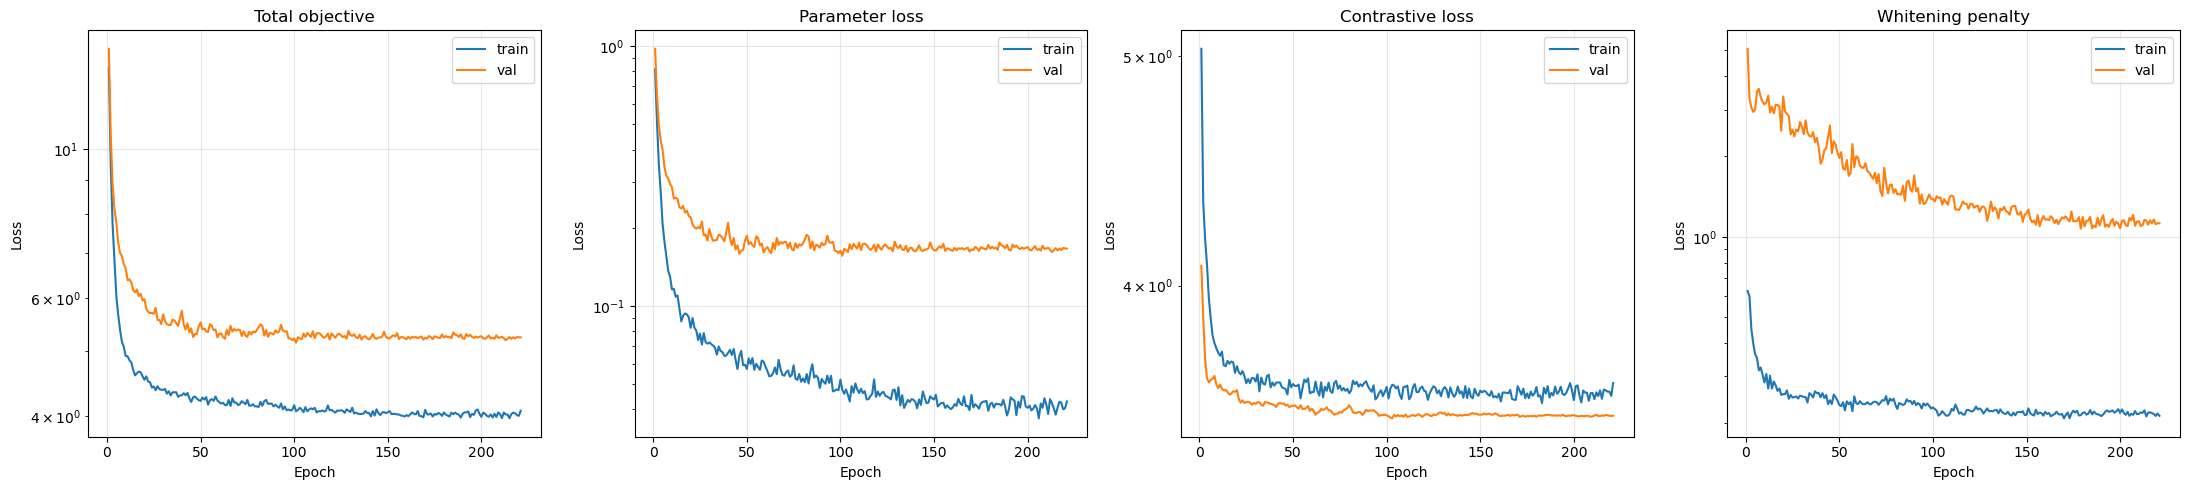

In [13]:
# ============================================================
# Train the Informative Autoencoder (Universal-SBI objective)
# ============================================================
# Loss:
#   L = λ_param * L_param + λ_contrast * L_contrast + λ_whiten * L_whiten + [λ_recon * L_recon]
#

#   L_param    = MSE(theta_norm, theta_hat_norm)
#   L_contrast = supervised contrastive loss on group IDs (same-theta consistency)
#   L_whiten   = latent covariance regularization toward identity
#   L_recon    = optional MSE(x, x_hat)
#

# Validation strategy: GROUP SPLIT on theta groups (unchanged).
# This remains critical for measuring generalization to unseen theta-values.
# ============================================================

# Fallback in case this cell is run without cell 13
try:
    LHC_GROUP_OFFSET
except NameError:
    LHC_GROUP_OFFSET = 9   # must match Cell 12

# --- Group-split setup ---
VAL_PARAM    = "q"    # "M_mw" | "M_lmc" | "c" | "q" | None
VAL_LHC_FRAC = 0.15   # fraction of LHC groups held out for validation (0 = none)

X_tensor      = torch.tensor(X_all, dtype=torch.float32)
theta_tensor  = torch.tensor(theta_norm, dtype=torch.float32)
group_tensor  = torch.tensor(theta_group, dtype=torch.long)

if VAL_PARAM is not None or VAL_LHC_FRAC > 0.0:
    val_groups = set()

    # --- Hold out the two perturbed groups for VAL_PARAM ---
    if VAL_PARAM is not None:
        val_groups |= {_group_map[(VAL_PARAM, "plus")], _group_map[(VAL_PARAM, "minus")]}

    # --- Hold out the last VAL_LHC_FRAC of LHC groups ---
    all_groups = np.unique(theta_group)
    lhc_groups = sorted([g for g in all_groups if g >= LHC_GROUP_OFFSET])
    n_lhc_val  = int(np.floor(VAL_LHC_FRAC * len(lhc_groups)))
    if n_lhc_val > 0:
        val_groups |= set(lhc_groups[-n_lhc_val:])

    val_mask   = np.isin(theta_group, list(val_groups))
    train_mask = ~val_mask

    train_idx = np.where(train_mask)[0]
    val_idx   = np.where(val_mask)[0]

    train_ds = TensorDataset(X_tensor[train_idx], theta_tensor[train_idx], group_tensor[train_idx])
    val_ds   = TensorDataset(X_tensor[val_idx],   theta_tensor[val_idx],   group_tensor[val_idx])
    n_train  = len(train_ds)
    n_val    = len(val_ds)
    print(f"Group-split (VAL_PARAM='{VAL_PARAM}', VAL_LHC_FRAC={VAL_LHC_FRAC}):")
    if VAL_PARAM is not None:
        print(f"  Held-out: {VAL_PARAM} plus/minus groups  ({sorted({_group_map[(VAL_PARAM,'plus')], _group_map[(VAL_PARAM,'minus')]})})")
    if n_lhc_val > 0:
        print(f"  Held-out: {n_lhc_val}/{len(lhc_groups)} LHC groups "
              f"(theta-values NOT seen during training)")
    print(f"  Train samples : {n_train}")
    print(f"  Val   samples : {n_val}  <- theta-values NOT seen during training")
else:
    # Fallback: original random split (kept for backward compatibility)
    dataset = TensorDataset(X_tensor, theta_tensor, group_tensor)
    n_val   = int(len(dataset) * VAL_FRAC)
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                     generator=torch.Generator().manual_seed(42))
    print(f"Random split : {n_train} train / {n_val} val")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True)   # avoid BN crash on batch-size-1 tail
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

if len(train_loader) == 0:
    raise RuntimeError(
        f"train_loader has 0 batches with BATCH_SIZE={BATCH_SIZE} and drop_last=True. "
        "Reduce BATCH_SIZE or disable drop_last.")

if n_train < BATCH_SIZE:
    raise RuntimeError(
        f"n_train={n_train} < BATCH_SIZE={BATCH_SIZE}. "
        "Reduce BATCH_SIZE or collect more training data.")

# --- Instantiate model ---
model = InformativeAutoencoder(
    input_dim=K_full_ae, latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS, regressor_hidden=REGRESSOR_HIDDEN,
    n_params=n_params_ae, dropout=DROPOUT,
).to(device)

n_model_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
print(f"Model parameters  : {n_model_params:,}")
print(f"Objective mode    : universal SBI")
print(f"Use recon loss    : {USE_RECON_LOSS}")
print(f"λ_param={LAMBDA_PARAM}, λ_contrast={LAMBDA_CONTRAST}, λ_whiten={LAMBDA_WHITEN}, λ_recon={LAMBDA_RECON}")

optimiser = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                             weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=30, min_lr=1e-6)

mse = nn.MSELoss()

# --- Training loop -------------------------------------------------------
history = {
    "train_total": [], "train_recon": [], "train_param": [], "train_contrast": [], "train_whiten": [],
    "val_total":   [], "val_recon":   [], "val_param":   [], "val_contrast":   [], "val_whiten":   [],
}

best_val_loss = np.inf
best_state    = None
wait          = 0

for epoch in range(1, N_EPOCHS + 1):
    # ---- Train ----
    model.train()
    acc_total = acc_recon = acc_param = acc_contrast = acc_whiten = acc_n = 0.0

    for xb, tb, gb in train_loader:
        xb = xb.to(device)
        tb = tb.to(device)
        gb = gb.to(device)

        x_hat, t_hat, z = model(xb, decode=USE_RECON_LOSS)

        loss_p = mse(t_hat, tb)
        loss_c = supervised_contrastive_loss(z, gb, temperature=CONTRASTIVE_TEMP)
        loss_w = latent_whitening_penalty(z, target_var=WHITEN_TARGET_VAR, eps=WHITEN_EPS)
        if USE_RECON_LOSS:
            loss_r = mse(x_hat, xb)
        else:
            loss_r = torch.zeros((), device=device)

        loss = (LAMBDA_PARAM * loss_p +
                LAMBDA_CONTRAST * loss_c +
                LAMBDA_WHITEN * loss_w +
                (LAMBDA_RECON * loss_r if USE_RECON_LOSS else 0.0))

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        bs = xb.size(0)
        acc_total    += loss.item() * bs
        acc_recon    += loss_r.item() * bs
        acc_param    += loss_p.item() * bs
        acc_contrast += loss_c.item() * bs
        acc_whiten   += loss_w.item() * bs
        acc_n        += bs

    tr_total    = acc_total / acc_n
    tr_recon    = acc_recon / acc_n
    tr_param    = acc_param / acc_n
    tr_contrast = acc_contrast / acc_n
    tr_whiten   = acc_whiten / acc_n

    history["train_total"].append(tr_total)
    history["train_recon"].append(tr_recon)
    history["train_param"].append(tr_param)
    history["train_contrast"].append(tr_contrast)
    history["train_whiten"].append(tr_whiten)

    # ---- Validate ----
    model.eval()
    v_total = v_recon = v_param = v_contrast = v_whiten = v_n = 0.0
    with torch.no_grad():
        for xv, tv, gv in val_loader:
            xv = xv.to(device)
            tv = tv.to(device)
            gv = gv.to(device)

            xv_hat, tv_hat, zv = model(xv, decode=USE_RECON_LOSS)

            vl_p = mse(tv_hat, tv)
            vl_c = supervised_contrastive_loss(zv, gv, temperature=CONTRASTIVE_TEMP)
            vl_w = latent_whitening_penalty(zv, target_var=WHITEN_TARGET_VAR, eps=WHITEN_EPS)
            if USE_RECON_LOSS:
                vl_r = mse(xv_hat, xv)
            else:
                vl_r = torch.zeros((), device=device)

            vl = (LAMBDA_PARAM * vl_p +
                  LAMBDA_CONTRAST * vl_c +
                  LAMBDA_WHITEN * vl_w +
                  (LAMBDA_RECON * vl_r if USE_RECON_LOSS else 0.0))

            bs_v = xv.size(0)
            v_total    += vl.item() * bs_v
            v_recon    += vl_r.item() * bs_v
            v_param    += vl_p.item() * bs_v
            v_contrast += vl_c.item() * bs_v
            v_whiten   += vl_w.item() * bs_v
            v_n        += bs_v

    if v_n > 0:
        vl_total    = v_total / v_n
        vl_recon    = v_recon / v_n
        vl_param    = v_param / v_n
        vl_contrast = v_contrast / v_n
        vl_whiten   = v_whiten / v_n

        history["val_total"].append(vl_total)
        history["val_recon"].append(vl_recon)
        history["val_param"].append(vl_param)
        history["val_contrast"].append(vl_contrast)
        history["val_whiten"].append(vl_whiten)
        scheduler.step(vl_total)

        # ---- Early stopping ----
        if vl_total < best_val_loss:
            best_val_loss = vl_total
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
    else:
        vl_total = vl_recon = vl_param = vl_contrast = vl_whiten = np.nan
        history["val_total"].append(np.nan)
        history["val_recon"].append(np.nan)
        history["val_param"].append(np.nan)
        history["val_contrast"].append(np.nan)
        history["val_whiten"].append(np.nan)

    if epoch % 50 == 0 or epoch == 1 or wait == PATIENCE:
        lr_now = optimiser.param_groups[0]["lr"]
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  "
              f"train L={tr_total:.4e} (P={tr_param:.4e} C={tr_contrast:.4e} W={tr_whiten:.4e} R={tr_recon:.4e})  "
              f"val L={vl_total:.4e} (P={vl_param:.4e} C={vl_contrast:.4e} W={vl_whiten:.4e} R={vl_recon:.4e})  "
              f"lr={lr_now:.1e}  wait={wait}")

    if wait >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}  (best val loss = {best_val_loss:.4e})")
        break

# ---- Restore best model ----
if best_state is not None:
    model.load_state_dict(best_state)
    model.eval()
    print(f"\n  Best model restored  (val loss = {best_val_loss:.4e})")
else:
    print("\n  No validation-selected checkpoint (validation set empty); keeping last epoch weights.")

# ---- Learning curves ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
epochs_arr = np.arange(1, len(history["train_total"]) + 1)

plot_specs = [
    ("total", "Total objective"),
    ("param", "Parameter loss"),
    ("contrast", "Contrastive loss"),
    ("whiten", "Whitening penalty"),
]

for ax, (key, title) in zip(axes, plot_specs):
    ax.semilogy(epochs_arr, history[f"train_{key}"], label="train", lw=1.5)
    ax.semilogy(epochs_arr, history[f"val_{key}"],   label="val",   lw=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


FISHER PIPELINE IN AE LATENT SPACE

Encoding COV pool for Cov(s) estimation (disjoint from training data)...
  S_cov shape  : (2000, 16)  (COV pool only)
  diag(Cov)    : [0.0318 0.0763 0.0379 0.0777 0.038  0.1038 0.0625 0.0309 0.0439 0.0866
 0.0313 0.0606 0.1099 0.0839 0.0363 0.0667]
  cond(Cov)    : 2.97e+02

Computing Jacobian using 100-seed averaged derivatives...
  Seed range: 5115 to 5214
  (disjoint from linear Fisher seeds 5015..5114)
  Loading 100 realizations for M_mw_plus...---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-300_L5_n40_nr4000.cache>
---- Spherical::orthoTest: worst=0.0502088
---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-300_L5_n40_nr4000.cache>
---- Spherical::orthoTest: worst=0.0502088
---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-3

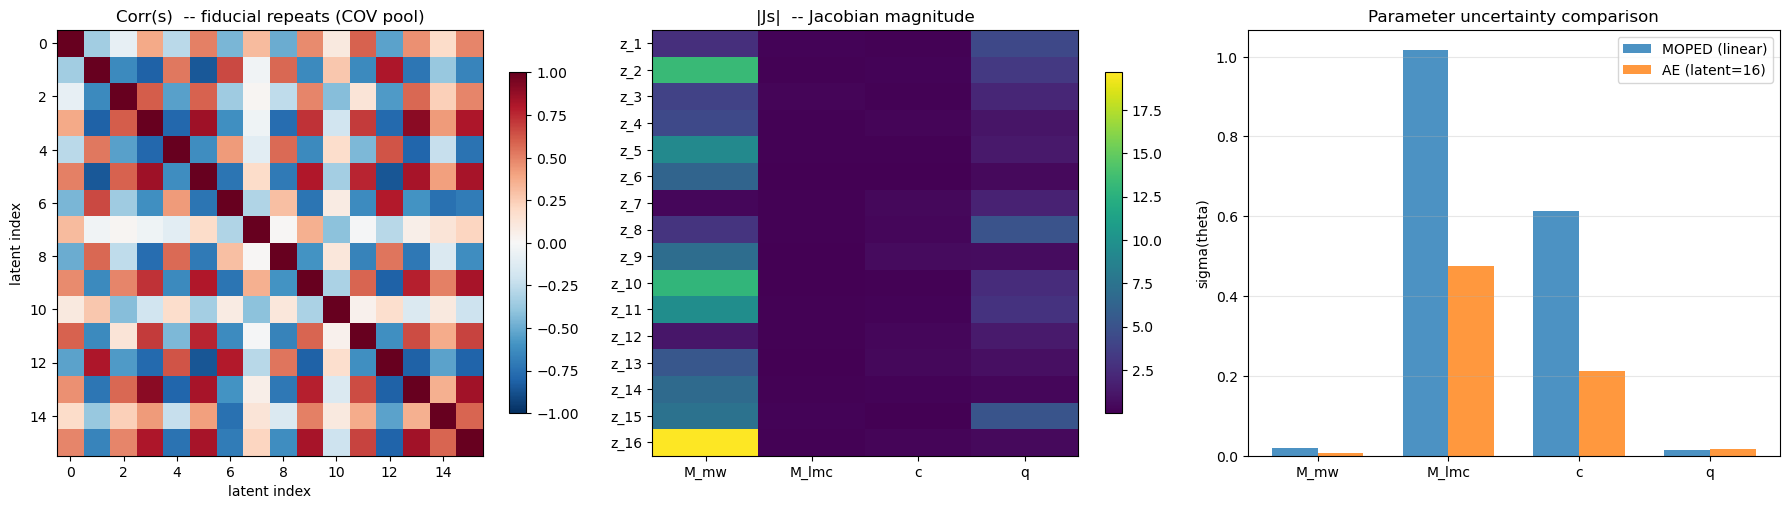


FISHER SIGMA vs NUMBER OF LATENT DIMENSIONS USED
n_latent  s_M_mw        s_M_lmc       s_c           s_q           
----------------------------------------------------------------------
1         inf           inf           inf           inf           
2         inf           inf           inf           inf           
3         inf           inf           inf           inf           
4         0.073355      1.537837      2.322579      0.375061      
5         0.062592      1.533758      1.960006      0.334616      
6         0.031466      1.532169      0.843980      0.145835      
7         0.017267      1.003206      0.612976      0.043806      
8         0.015602      1.003134      0.505970      0.031090      
9         0.007330      0.623739      0.251187      0.028110      
10        0.007158      0.555307      0.237858      0.028108      
11        0.006853      0.540651      0.230674      0.025507      
12        0.006733      0.501182      0.222154      0.023857      
13      

In [14]:
# ============================================================
# Fisher Pipeline in AE Latent Space
# ============================================================
# The trained encoder  s = enc(r_moped)  replaces the linear
# U1 projection.  Unlike the linear case, Cov(s) != I in general,
# so we estimate it from fiducial repeats and invert it.
#
#   Jacobian:  Js[:, a] = (s+_a - s-_a) / (2 * dtheta_a)
#   Fisher  :  F = Js.T @ Cov(s)^{-1} @ Js
#   Covar.  :  Sigma = F^{-1}
#
# SEED PARTITIONS (disjoint from linear Fisher & training data):
#   Cov(s) estimation : COV pool (indices 0..N_COV_REPEATS-1, from moped_results["R_ext"])
#   AE Jacobian       : BASE_SEED_AE_DERIV + [0, N_REALIZATIONS)
# ============================================================

if "moped_results" not in globals():
    raise RuntimeError("moped_results not found — run cell 9 (MOPED compression) first.")
if "model" not in globals():
    raise RuntimeError("model not found — run cell 10 (AE definition) and cell 13 (AE training) first.")

print("\n" + "="*70)
print("FISHER PIPELINE IN AE LATENT SPACE")
print("="*70)

params_ae = list(moped_results["params"])  # ["M_mw", "M_lmc", "c", "q"]
n_p       = len(params_ae)

# Fallbacks for standalone execution (if Cell 9 was skipped)
try:
    BASE_SEED
except NameError:
    _fid_base = 2015
    _n_cov = int(globals().get('N_COV_REPEATS', 2000))
    _n_train_fid = int(globals().get('N_TRAIN_FID', 1000))
    BASE_SEED = _fid_base + _n_cov + _n_train_fid
    print(f"  Warning: BASE_SEED not defined, using fallback = {BASE_SEED}")
try:
    BASE_SEED_AE_DERIV
except NameError:
    _n_real = int(globals().get('N_REALIZATIONS', 100))
    BASE_SEED_AE_DERIV = BASE_SEED + _n_real
    print(f"  Warning: BASE_SEED_AE_DERIV not defined, using fallback = {BASE_SEED_AE_DERIV}")
try:
    N_REALIZATIONS
except NameError:
    N_REALIZATIONS = 100
    print(f"  Warning: N_REALIZATIONS not defined, using fallback = {N_REALIZATIONS}")

# Set eval mode ONCE here — not inside encode_np (redundant per-call overhead)
model.eval()

# ---- Helper: batch-encode MOPED summaries (2D or 1D) -------------------
ENCODE_BATCH = 512   # max rows per GPU call; avoids OOM on large arrays

@torch.no_grad()
def encode_batch(X_moped):
    """
    Encode a 2-D MOPED array (N, K) -> latent codes (N, L) as numpy float64.
    Also accepts a 1-D input (K,) and returns (L,).
    """
    squeeze = (X_moped.ndim == 1)
    if squeeze:
        X_moped = X_moped[np.newaxis, :]
    codes = []
    for i in range(0, len(X_moped), ENCODE_BATCH):
        xb = torch.tensor(X_moped[i:i+ENCODE_BATCH], dtype=torch.float32).to(device)
        codes.append(model.encode(xb).cpu().numpy())
    result = np.vstack(codes)
    return result.squeeze(0) if squeeze else result

def encode_np(f_raw):
    """
    Raw features (D,) -> AE latent code (L,) as numpy.
    Applies standardisation + MOPED compression before encoding.
    """
    f_moped = apply_moped(apply_standardization(f_raw))
    return encode_batch(f_moped)   # (L,)

# ---- 1. Empirical covariance from COV pool (disjoint from training) ----
print("\nEncoding COV pool for Cov(s) estimation (disjoint from training data)...")
# Use already-projected MOPED summaries (computed in cell 9): R_ext[:N_COV_REPEATS]
X_cov_moped = moped_results["R_ext"][:N_COV_REPEATS]           # (N_COV_REPEATS, K)
S_cov        = encode_batch(X_cov_moped)                        # (N_COV_REPEATS, L)

Cov_s    = np.cov(S_cov, rowvar=False, ddof=1)               # (L, L)
cond_Cov = np.linalg.cond(Cov_s)
# Small ridge prevents inversion failure when any latent dim is near-constant
_ridge_scale = max(1e-6, 1e-6 * np.diag(Cov_s).mean())
_ridge       = _ridge_scale * np.eye(LATENT_DIM)
try:
    Cov_inv = np.linalg.inv(Cov_s + _ridge)
except np.linalg.LinAlgError:
    Cov_inv = np.linalg.pinv(Cov_s)
print(f"  S_cov shape  : {S_cov.shape}  (COV pool only)")
print(f"  diag(Cov)    : {np.diag(Cov_s).round(4)}")
warn_str = "  WARNING: ill-conditioned" if cond_Cov > 1e6 else ""
print(f"  cond(Cov)    : {cond_Cov:.2e}{warn_str}")

# ---- 2. Jacobian in AE latent space (disjoint seeds from linear Fisher) ---
print(f"\nComputing Jacobian using {N_REALIZATIONS}-seed averaged derivatives...")
print(f"  Seed range: {BASE_SEED_AE_DERIV} to {BASE_SEED_AE_DERIV + N_REALIZATIONS - 1}")
print(f"  (disjoint from linear Fisher seeds {BASE_SEED}..{BASE_SEED + N_REALIZATIONS - 1})")
Js = np.zeros((LATENT_DIM, n_p))

for a, pname in enumerate(params_ae):
    dp = step_frac[pname] * float(theta_star[pname])
    fp_raw = feature_fn_fisher_averaged(pname, "plus",
                include_velocity_moments=INCLUDE_VELOCITY_MOMENTS,
                n_realizations=N_REALIZATIONS, base_seed=BASE_SEED_AE_DERIV)
    fm_raw = feature_fn_fisher_averaged(pname, "minus",
                include_velocity_moments=INCLUDE_VELOCITY_MOMENTS,
                n_realizations=N_REALIZATIONS, base_seed=BASE_SEED_AE_DERIV)
    sp = encode_np(fp_raw)
    sm = encode_np(fm_raw)
    Js[:, a] = (sp - sm) / (2.0 * dp)
    print(f"  d(s)/d({pname:<6s})  ||J|| = {np.linalg.norm(Js[:, a]):.4e}")

# ---- 3. Fisher matrix --------------------------------------------------
F_ae    = Js.T @ Cov_inv @ Js
try:
    Sigma_ae = np.linalg.inv(F_ae)
except np.linalg.LinAlgError:
    Sigma_ae = np.linalg.pinv(F_ae)

sigma_ae = np.sqrt(np.clip(np.diag(Sigma_ae), 0, np.inf))
_safe_sigma_ae = np.where(sigma_ae < 1e-30, 1.0, sigma_ae)  # guard: avoid NaN for degenerate params
corr_ae  = Sigma_ae / np.outer(_safe_sigma_ae, _safe_sigma_ae)

# ---- Reference: linear MOPED sigma ------------------------------------
sigma_lin = np.array([moped_results["sigma"][p] for p in params_ae])

# ---- Print results table -----------------------------------------------
print(f"\n{'='*70}")
print(f"PARAMETER CONSTRAINTS: AE (latent={LATENT_DIM}) vs MOPED (linear)")
print(f"{'='*70}")
print(f"{'Param':<10} {'sigma (MOPED)':<18} {'sigma (AE)':<16} {'Ratio':<10} {'sigma/theta*'}")
print("-"*70)
for a, pname in enumerate(params_ae):
    ratio = sigma_ae[a] / sigma_lin[a] if sigma_lin[a] > 0 else np.inf
    pct   = 100 * sigma_ae[a] / float(theta_star[pname])
    print(f"{pname:<10} {sigma_lin[a]:<18.6f} {sigma_ae[a]:<16.6f} x{ratio:<8.3f} ({pct:.2f}%)")

# ---- Jacobian matrix ---------------------------------------------------
header = f"{'':>10}" + "".join(f"{p:>14}" for p in params_ae)
print(f"\nJacobian Js  ({LATENT_DIM} x {n_p}):")
print(header)
for i in range(LATENT_DIM):
    row = f"  z_{i+1:<6}" + "".join(f"{Js[i, a]:>+14.4e}" for a in range(n_p))
    print(row)

# ---- Parameter correlation matrix --------------------------------------
print(f"\nParameter correlation matrix (AE):")
print(header)
for a, pa in enumerate(params_ae):
    row = f"{pa:<10}" + "".join(f"{corr_ae[a, b]:>14.4f}" for b in range(n_p))
    print(row)

# ---- Visualisation: latent-space diagnostics ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Correlation matrix of latent code
ax = axes[0]
_std_s  = np.sqrt(np.diag(Cov_s))
_std_s  = np.where(_std_s < 1e-30, 1.0, _std_s)   # guard: avoid NaN for dead dims
_corr_s = Cov_s / np.outer(_std_s, _std_s)
im = ax.imshow(_corr_s, cmap="RdBu_r", origin="upper", vmin=-1, vmax=1)
ax.set_title("Corr(s)  -- fiducial repeats (COV pool)")
ax.set_xlabel("latent index")
ax.set_ylabel("latent index")
plt.colorbar(im, ax=ax, shrink=0.8)

# Panel 2: |Js| heatmap (how each latent dimension loads on each parameter)
ax = axes[1]
im2 = ax.imshow(np.abs(Js), aspect="auto", cmap="viridis")
ax.set_yticks(range(LATENT_DIM))
ax.set_yticklabels([f"z_{i+1}" for i in range(LATENT_DIM)])
ax.set_xticks(range(n_p))
ax.set_xticklabels(params_ae)
ax.set_title("|Js|  -- Jacobian magnitude")
plt.colorbar(im2, ax=ax, shrink=0.8)

# Panel 3: sigma comparison bar chart (AE vs MOPED linear)
ax = axes[2]
x_pos = np.arange(n_p)
w = 0.35
ax.bar(x_pos - w/2, sigma_lin, w, label="MOPED (linear)", alpha=0.8)
ax.bar(x_pos + w/2, sigma_ae,  w, label=f"AE (latent={LATENT_DIM})", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(params_ae)
ax.set_ylabel("sigma(theta)")
ax.set_title("Parameter uncertainty comparison")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ---- Latent-dim sweep: Fisher sigma vs number of latent dims used ------
print(f"\n{'='*70}")
print("FISHER SIGMA vs NUMBER OF LATENT DIMENSIONS USED")
print("="*70)

# Compute Fisher from subsets of latent dims ordered by descending variance
var_order    = np.argsort(np.diag(Cov_s))[::-1]
header_sweep = f"{'n_latent':<10}" + "".join(f"{'s_'+p:<14}" for p in params_ae)
print(header_sweep)
print("-"*70)

PINV_RCOND = 1e-10  # rcond for pseudo-inverse (avoids nonsense from near-singular matrices)

for n_use in range(1, LATENT_DIM + 1):
    # If n_use < n_params, Fisher matrix cannot be full rank → σ = ∞
    if n_use < n_p:
        sig_sub = np.full(n_p, np.inf)
        print(f"{n_use:<10}" + "".join(f"{s:<14}" for s in sig_sub))
        continue

    idx        = var_order[:n_use]
    Js_sub     = Js[idx, :]                              # (n_use, n_p)
    Cov_sub    = Cov_s[np.ix_(idx, idx)]                 # (n_use, n_use)

    # Stable inverse for covariance block (symmetrize first)
    Cov_sub = 0.5 * (Cov_sub + Cov_sub.T)
    Covinv_sub = np.linalg.pinv(Cov_sub + _ridge_scale * np.eye(n_use), rcond=PINV_RCOND)

    # Fisher block
    F_sub = Js_sub.T @ Covinv_sub @ Js_sub               # (n_p, n_p)
    F_sub = 0.5 * (F_sub + F_sub.T)

    # Use pseudo-inverse to avoid nonsense from near-singular inverses
    Sig_sub = np.linalg.pinv(F_sub, rcond=PINV_RCOND)
    Sig_sub = 0.5 * (Sig_sub + Sig_sub.T)

    sig_sub = np.sqrt(np.clip(np.diag(Sig_sub), 0.0, np.inf))
    print(f"{n_use:<10}" + "".join(f"{s:<14.6f}" for s in sig_sub))

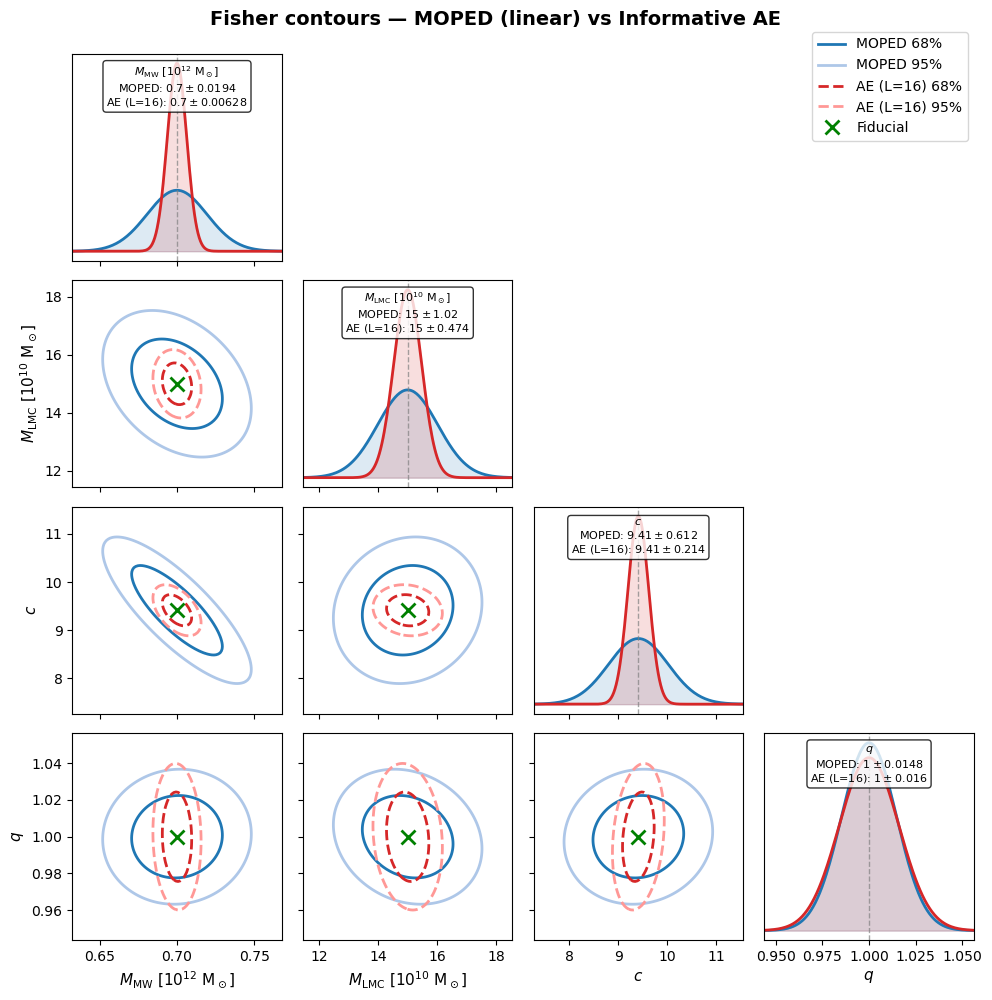

In [17]:
# ----------------------------
# Visualize Fisher Matrix Results - Corner Plot
# ----------------------------
def plot_fisher_corner(fisher_results, nsigma=[1, 2], npoints=100,
                       fisher_results_2=None, label1="Linear", label2="AE"):
    """
    Create a corner plot showing Fisher matrix constraints.
    Optionally overlay a second set of contours for comparison.
    
    Args:
        fisher_results: Dictionary with keys "params", "theta_star", "Sigma", "sigma"
        nsigma: List of confidence levels to plot (in sigma)
        npoints: Number of points for contour lines
        fisher_results_2: Optional second results dict for overlay
        label1, label2: Labels for the two sets of contours
    """
    params = fisher_results["params"]
    theta_star_plot = fisher_results["theta_star"]
    Sigma = fisher_results["Sigma"]
    sigma = fisher_results["sigma"]
    
    nparams = len(params)
    
    fig, axes = plt.subplots(nparams, nparams, figsize=(10, 10))
    
    param_labels = {
        "M_mw": r"$M_{\rm MW}$ [$10^{12}$ M$_\odot$]",
        "M_lmc": r"$M_{\rm LMC}$ [$10^{10}$ M$_\odot$]",
        "c": r"$c$",
        "q": r"$q$"
    }
    
    colors_1 = ['#1f77b4', '#aec7e8']   # blue solid/light for set 1
    colors_2 = ['#d62728', '#ff9896']    # red solid/light for set 2

    for i in range(nparams):
        for j in range(nparams):
            ax = axes[i, j]
            
            if i < j:
                ax.axis('off')
                
            elif i == j:
                param = params[i]
                mean = theta_star_plot[param]
                std1 = sigma[param]
                
                x1 = np.linspace(mean - 4*std1, mean + 4*std1, 200)
                y1 = np.exp(-0.5 * ((x1 - mean) / std1)**2) / (std1 * np.sqrt(2 * np.pi))
                ax.plot(x1, y1, '-', lw=2, color=colors_1[0])
                ax.fill_between(x1, 0, y1, alpha=0.15, color=colors_1[0])
                
                if fisher_results_2 is not None:
                    std2 = fisher_results_2["sigma"][param]
                    x2 = np.linspace(mean - 4*max(std1, std2), mean + 4*max(std1, std2), 200)
                    y2 = np.exp(-0.5 * ((x2 - mean) / std2)**2) / (std2 * np.sqrt(2 * np.pi))
                    ax.plot(x2, y2, '-', lw=2, color=colors_2[0])
                    ax.fill_between(x2, 0, y2, alpha=0.15, color=colors_2[0])
                    txt = (f'{param_labels[param]}\n'
                           f'{label1}: ${mean:.3g} \\pm {std1:.3g}$\n'
                           f'{label2}: ${mean:.3g} \\pm {std2:.3g}$')
                    xlim_std = max(std1, std2)
                else:
                    txt = f'{param_labels[param]}\n${mean:.3g} \\pm {std1:.3g}$'
                    xlim_std = std1
                
                ax.axvline(mean, color='gray', linestyle='--', lw=1, alpha=0.7)
                ax.text(0.5, 0.95, txt,
                       transform=ax.transAxes, ha='center', va='top',
                       fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                ax.set_xlim(mean - 3.5*xlim_std, mean + 3.5*xlim_std)
                ax.set_yticks([])
                
                if i == nparams - 1:
                    ax.set_xlabel(param_labels[param], fontsize=11)
                else:
                    ax.set_xticklabels([])
                    
            else:
                param_x = params[j]
                param_y = params[i]
                mean_x = theta_star_plot[param_x]
                mean_y = theta_star_plot[param_y]
                
                # --- Set 1 contours ---
                cov_2d = Sigma[np.ix_([i, j], [i, j])]
                cov_2d = cov_2d[[1, 0], :][:, [1, 0]]
                std_x1 = np.sqrt(cov_2d[0, 0])
                std_y1 = np.sqrt(cov_2d[1, 1])
                
                span_x, span_y = std_x1, std_y1
                if fisher_results_2 is not None:
                    cov2_2d = fisher_results_2["Sigma"][np.ix_([i, j], [i, j])]
                    cov2_2d = cov2_2d[[1, 0], :][:, [1, 0]]
                    span_x = max(span_x, np.sqrt(cov2_2d[0, 0]))
                    span_y = max(span_y, np.sqrt(cov2_2d[1, 1]))
                
                x_range = np.linspace(mean_x - 3.5*span_x, mean_x + 3.5*span_x, npoints)
                y_range = np.linspace(mean_y - 3.5*span_y, mean_y + 3.5*span_y, npoints)
                X, Y = np.meshgrid(x_range, y_range)
                
                def _draw_contours(cov, colors, ls='-'):
                    cov_inv = np.linalg.inv(cov)
                    diff = np.stack([X - mean_x, Y - mean_y], axis=-1)
                    chi2 = np.einsum('...i,ij,...j->...', diff, cov_inv, diff)
                    for lev, col in zip([2.30, 6.17], colors):
                        ax.contour(X, Y, chi2, levels=[lev],
                                   colors=[col], linewidths=2, linestyles=[ls])
                
                _draw_contours(cov_2d, colors_1, ls='-')
                if fisher_results_2 is not None:
                    _draw_contours(cov2_2d, colors_2, ls='--')
                
                ax.plot(mean_x, mean_y, 'gx', markersize=10, markeredgewidth=2)
                ax.set_xlim(mean_x - 3.5*span_x, mean_x + 3.5*span_x)
                ax.set_ylim(mean_y - 3.5*span_y, mean_y + 3.5*span_y)
                
                if i == nparams - 1:
                    ax.set_xlabel(param_labels[param_x], fontsize=11)
                else:
                    ax.set_xticklabels([])
                if j == 0:
                    ax.set_ylabel(param_labels[param_y], fontsize=11)
                else:
                    ax.set_yticklabels([])
    
    fig.suptitle('Fisher contours — MOPED (linear) vs Informative AE',
                 fontsize=14, fontweight='bold', y=0.995)
    
    legend_elements = [
        Line2D([0], [0], color=colors_1[0], lw=2, label=f'{label1} 68%'),
        Line2D([0], [0], color=colors_1[1], lw=2, label=f'{label1} 95%'),
    ]
    if fisher_results_2 is not None:
        legend_elements += [
            Line2D([0], [0], color=colors_2[0], lw=2, ls='--', label=f'{label2} 68%'),
            Line2D([0], [0], color=colors_2[1], lw=2, ls='--', label=f'{label2} 95%'),
        ]
    legend_elements.append(
        Line2D([0], [0], marker='x', color='g', lw=0, markersize=10,
               markeredgewidth=2, label='Fiducial'))
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10,
              bbox_to_anchor=(0.98, 0.98))
    plt.tight_layout()
    return fig

# ---- Build results dicts ----
fisher_lin_results = {
    "params":     params_ae,
    "theta_star": theta_star,
    "Sigma":      moped_results["Sigma"],
    "sigma":      moped_results["sigma"],
}

fisher_ae_results = {
    "params":     params_ae,
    "theta_star": theta_star,
    "Sigma":      Sigma_ae,
    "sigma":      dict(zip(params_ae, sigma_ae)),
}

fig = plot_fisher_corner(fisher_lin_results,
                         fisher_results_2=fisher_ae_results,
                         label1="MOPED", label2=f"AE (L={LATENT_DIM})")
plt.show()

In [16]:
# ----------------------------
# Save AE Fisher Results + Model/Encoder Checkpoints
# ----------------------------

# 1) Full model checkpoint (keeps previous behaviour)
model_path = "/g/data/y89/ys9983/CFM_MW_LMC/ae_encoder_checkpoint.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim":        K_full_ae,
    "latent_dim":       LATENT_DIM,
    "hidden_dims":      HIDDEN_DIMS,
    "regressor_hidden": REGRESSOR_HIDDEN,
    "n_params":         n_params_ae,
    "dropout":          DROPOUT,
    "theta_mean":       theta_mean,
    "theta_std":        theta_std,
    "history":          history,
}, model_path)
print(f"✓ Full model checkpoint saved to: {model_path}")

# 2) Encoder-only bundle for transfer to new-theta validation
# Includes full preprocessing state so transfer runs are self-contained.
encoder_path = "/g/data/y89/ys9983/CFM_MW_LMC/ae_encoder_only.pt"
torch.save({
    "encoder_state_dict": model.encoder.state_dict(),
    "input_dim":          K_full_ae,
    "latent_dim":         LATENT_DIM,
    "hidden_dims":        HIDDEN_DIMS,
    "dropout":            DROPOUT,
    "n_summaries":        int(moped_results["N_SUMMARIES"]),
    "include_velocity_moments": bool(INCLUDE_VELOCITY_MOMENTS),

    # feature standardization (from COV pool)
    "feature_mean":       std_means,
    "feature_std":        std_stds,
    "feature_mask":       std_mask.astype(np.bool_),

    # MOPED projection + centering in standardized space
    "moped_center":       moped_results["mu_std"],
    "moped_projection":   moped_results["Q_ext"],

    # backward-compatible aliases
    "std_mu":             moped_results["mu_std"],
    "Q_ext":              moped_results["Q_ext"],

    # metadata
    "theta_star_train":   np.array([float(theta_star[p]) for p in params_ae]),
    "params":             np.array(params_ae),
}, encoder_path)
print(f"✓ Encoder-only bundle saved to: {encoder_path}")

# Save Fisher results
output_path = "/g/data/y89/ys9983/CFM_MW_LMC/bfe_fisher_ae_results.npz"
np.savez(
    output_path,
    Fisher_ae=F_ae,
    Covariance_ae=Sigma_ae,
    Correlation_ae=corr_ae,
    Jacobian_ae=Js,
    Cov_latent=Cov_s,
    sigma_ae=sigma_ae,
    # MOPED baseline for comparison
    Fisher_linear=moped_results["F"],
    sigma_linear=np.array([moped_results["sigma"][p] for p in params_ae]),
    # Metadata
    params=np.array(params_ae),
    theta_star=np.array([float(theta_star[p]) for p in params_ae]),
    latent_dim=LATENT_DIM,
    lambda_param=LAMBDA_PARAM,
    n_epochs_trained=len(history["train_total"]),
    best_val_loss=best_val_loss,
)
print(f"✓ Fisher results saved to: {output_path}")

# Print summary
print(f"\n{'='*70}")
print("INFORMATIVE AE FISHER ANALYSIS SUMMARY")
print(f"{'='*70}")
print(f"  Input dim           : {K_full_ae}")
print(f"  Latent dim          : {LATENT_DIM}")
print(f"  Architecture        : {' → '.join(str(d) for d in [K_full_ae]+HIDDEN_DIMS+[LATENT_DIM])}")
print(f"  λ (param weight)    : {LAMBDA_PARAM}")
print(f"  Epochs trained      : {len(history['train_total'])}")
print(f"  Best val loss       : {best_val_loss:.4e}")
print(f"\n{'Param':<10} {'σ (MOPED)':<16} {'σ (AE)':<16} {'Ratio':<10}")
print("-"*55)
for a, p in enumerate(params_ae):
    s_lin = moped_results["sigma"][p]
    s_ae  = sigma_ae[a]
    ratio = s_ae / s_lin if s_lin > 0 else np.inf
    print(f"{p:<10} {s_lin:<16.6f} {s_ae:<16.6f} ×{ratio:<8.3f}")
print("="*70)

✓ Full model checkpoint saved to: /g/data/y89/ys9983/CFM_MW_LMC/ae_encoder_checkpoint.pt
✓ Encoder-only bundle saved to: /g/data/y89/ys9983/CFM_MW_LMC/ae_encoder_only.pt
✓ Fisher results saved to: /g/data/y89/ys9983/CFM_MW_LMC/bfe_fisher_ae_results.npz

INFORMATIVE AE FISHER ANALYSIS SUMMARY
  Input dim           : 200
  Latent dim          : 16
  Architecture        : 200 → 256 → 64 → 16
  λ (param weight)    : 10.0
  Epochs trained      : 221
  Best val loss       : 5.1508e+00

Param      σ (MOPED)        σ (AE)           Ratio     
-------------------------------------------------------
M_mw       0.019367         0.006276         ×0.324   
M_lmc      1.016043         0.474402         ×0.467   
c          0.612075         0.213502         ×0.349   
q          0.014777         0.016049         ×1.086   


In [7]:
# ----------------------------
# Helper: use saved encoder at new theta + sample budget calculator
# ----------------------------

def fisher_sample_budget(n_params=4, n_cov=2000, n_deriv=100):
    """
    Return sample counts for local Fisher evaluation at a new fiducial theta.

    n_cov   : fiducial repeats used to estimate Cov(s)
    n_deriv : repeats per + and - perturbation used to estimate each Jacobian column
    total   : n_cov + 2*n_params*n_deriv
    """
    total = int(n_cov + 2 * n_params * n_deriv)
    return {
        "n_params": int(n_params),
        "n_cov": int(n_cov),
        "n_deriv_each_sign": int(n_deriv),
        "n_perturbed_total": int(2 * n_params * n_deriv),
        "n_total": total,
    }

# Bug fix 3: use a literal default n_params=4 instead of len(params_ae),
# which would raise NameError if Cell 13 has not been run.
_n_params_budget = len(params_ae) if "params_ae" in globals() else 4
print("Suggested sample budgets for NEW fiducial theta:")
print("  robust (current notebook policy)", fisher_sample_budget(n_params=_n_params_budget, n_cov=2000, n_deriv=100))
print("  quick-check", fisher_sample_budget(n_params=_n_params_budget, n_cov=1000, n_deriv=50))


class EncoderOnly(nn.Module):
    def __init__(self, input_dim, latent_dim=16, hidden_dims=(256, 64), dropout=0.10):
        super().__init__()
        enc = []
        prev = input_dim
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        enc.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*enc)

    def encode(self, x):
        return self.encoder(x)


@torch.no_grad()
def encode_raw_features_with_saved_encoder(
    raw_features,
    encoder_bundle_path="/g/data/y89/ys9983/CFM_MW_LMC/ae_encoder_only.pt",
    batch=512,
):
    """
    raw_features: np.ndarray shape (D,) or (N, D) in the SAME raw feature convention used in training.

    Pipeline: raw -> standardize -> MOPED projection -> encoder -> latent s.
    Returns latent array shape (L,) or (N, L).

    Fully self-contained: all preprocessing state is read from encoder_bundle_path.
    No session globals (device, std_means, Q_ext, ...) are required.
    """
    # Bug fix 1: weights_only=False is required because the bundle contains numpy arrays.
    # PyTorch >= 2.6 defaults to weights_only=True, which rejects numpy data.
    bundle = torch.load(encoder_bundle_path, map_location="cpu", weights_only=False)

    # Bug fix 2: resolve device locally so this function works in a fresh session.
    _device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Rebuild encoder
    net = EncoderOnly(
        input_dim=int(bundle["input_dim"]),
        latent_dim=int(bundle["latent_dim"]),
        hidden_dims=tuple(bundle["hidden_dims"]),
        dropout=float(bundle["dropout"]),
    ).to(_device)
    net.encoder.load_state_dict(bundle["encoder_state_dict"])
    net.eval()

    # Preprocessing arrays (new key names with backward-compatible fallback)
    mu_std = np.asarray(bundle.get("moped_center", bundle["std_mu"]), dtype=np.float64)
    Q_ext  = np.asarray(bundle.get("moped_projection", bundle["Q_ext"]), dtype=np.float64)

    X = np.asarray(raw_features, dtype=np.float64)
    squeeze = (X.ndim == 1)
    if squeeze:
        X = X[None, :]

    # Step 1: raw -> standardized (using saved COV-pool stats from bundle)
    if all(k in bundle for k in ["feature_mean", "feature_std", "feature_mask"]):
        feat_mean = np.asarray(bundle["feature_mean"], dtype=np.float64)
        feat_std  = np.asarray(bundle["feature_std"],  dtype=np.float64)
        feat_mask = np.asarray(bundle["feature_mask"], dtype=bool)
        X_std = np.zeros_like(X)
        X_std[:, feat_mask] = (X[:, feat_mask] - feat_mean[feat_mask]) / feat_std[feat_mask]
    elif "apply_standardization" in globals():
        # Backward compatibility: old bundle missing feature stats, fall back to session function
        X_std = np.vstack([apply_standardization(x) for x in X])
    else:
        raise RuntimeError(
            "Encoder bundle missing feature standardization stats and apply_standardization "
            "is not available. Re-save encoder bundle from Cell 15."
        )

    # Step 2: standardized -> MOPED summaries:  r = Q_ext^T @ (f_std - mu_std)
    X_mop = (Q_ext.T @ (X_std - mu_std[None, :]).T).T  # (N, K)

    # Step 3: MOPED summaries -> latent codes
    chunks = []
    for i in range(0, len(X_mop), batch):
        xb = torch.tensor(X_mop[i:i+batch], dtype=torch.float32, device=_device)
        zb = net.encode(xb).cpu().numpy()
        chunks.append(zb)

    Z = np.vstack(chunks)
    return Z.squeeze(0) if squeeze else Z

print("✓ Helper loaded. encode_raw_features_with_saved_encoder is fully self-contained.")
print("  Bugs fixed: weights_only=False, local device resolution, safe params_ae reference.")

Suggested sample budgets for NEW fiducial theta:
  robust (current notebook policy) {'n_params': 4, 'n_cov': 2000, 'n_deriv_each_sign': 100, 'n_perturbed_total': 800, 'n_total': 2800}
  quick-check {'n_params': 4, 'n_cov': 1000, 'n_deriv_each_sign': 50, 'n_perturbed_total': 400, 'n_total': 1400}
✓ Helper loaded. encode_raw_features_with_saved_encoder is fully self-contained.
  Bugs fixed: weights_only=False, local device resolution, safe params_ae reference.


In [9]:
# ============================================================
# Test-theta suite transfer pipeline (after Cell 16)
# 1) Read test theta suites + generated samples
# 2) Build BFE coefficients with current basis
# 3) Compress 16,800-D features with both linear MOPED and trained AE
# 4) Fisher analysis from compressed summaries
# 5) Universality diagnostics across suites
# ============================================================

# Imports are centralized in cell 1.

# ----------------------------
# User controls
# ----------------------------
TEST_SUITES_ROOT = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/test_theta_suites"
TEST_MANIFEST_PATH = os.path.join(TEST_SUITES_ROOT, "test_theta_suite_manifest.npz")
ENCODER_BUNDLE_PATH = "/g/data/y89/ys9983/CFM_MW_LMC/ae_encoder_only.pt"

# Evaluate subset/range of suites if needed
EVAL_SUITE_START = 0
EVAL_SUITE_STOP = None   # None => all available suites
EVAL_MAX_SUITES = 1   # optional hard cap after range slicing

# Expected counts from generation policy
EVAL_N_COV = 2000
EVAL_N_DERIV = 100

# Use cached compressed summaries (per suite) if present
EVAL_USE_CACHE = True
EVAL_FORCE_REBUILD_CACHE = False

# BFE config (matches current notebook policy)
BFE_CFG = dict(
    workdir="/g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw",
    rs_kpc=16.0,
    rmin_basis_kpc=0.5,
    rmax_basis_kpc=300.0,
    lmax=5,
    nmax=40,
    numr=4000,
    cache_name="fixed_nfw.cache",
)

# Step fractions used for finite differences
STEP_FRAC = {"M_mw": 0.05, "M_lmc": 0.5, "c": 0.3, "q": 0.05}
PARAMS = ["M_mw", "M_lmc", "c", "q"]


def _seed_from_name(path):
    m = re.search(r"seed(\d+)\.fits$", os.path.basename(path))
    return int(m.group(1)) if m else -1


def _ensure_encoder_class():
    if "EncoderOnly" not in globals():
        raise RuntimeError(
            "EncoderOnly is not defined. Run cell 16 first so the existing class is reused."
        )


def load_transfer_compression_state(bundle_path=ENCODER_BUNDLE_PATH):
    _ensure_encoder_class()
    bundle = torch.load(bundle_path, map_location="cpu", weights_only=False)

    required = ["encoder_state_dict", "input_dim", "latent_dim", "hidden_dims", "dropout"]
    missing = [k for k in required if k not in bundle]
    if missing:
        raise KeyError(f"Bundle missing required keys: {missing}")

    if not all(k in bundle for k in ["feature_mean", "feature_std", "feature_mask"]):
        raise KeyError(
            "Bundle missing feature standardization arrays. "
            "Re-save ae_encoder_only.pt from your training notebook (save cell)."
        )

    if "moped_center" in bundle:
        mu_std = np.asarray(bundle["moped_center"], dtype=np.float64)
    elif "std_mu" in bundle:
        mu_std = np.asarray(bundle["std_mu"], dtype=np.float64)
    else:
        raise KeyError("Bundle missing moped_center/std_mu")

    if "moped_projection" in bundle:
        Q_ext = np.asarray(bundle["moped_projection"], dtype=np.float64)
    elif "Q_ext" in bundle:
        Q_ext = np.asarray(bundle["Q_ext"], dtype=np.float64)
    else:
        raise KeyError("Bundle missing moped_projection/Q_ext")

    feat_mean = np.asarray(bundle["feature_mean"], dtype=np.float64)
    feat_std  = np.asarray(bundle["feature_std"],  dtype=np.float64)
    feat_mask = np.asarray(bundle["feature_mask"], dtype=bool)

    if feat_mean.shape != feat_std.shape or feat_mean.shape != feat_mask.shape:
        raise ValueError("feature_mean/feature_std/feature_mask shape mismatch")

    _device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net = EncoderOnly(
        input_dim=int(bundle["input_dim"]),
        latent_dim=int(bundle["latent_dim"]),
        hidden_dims=tuple(bundle["hidden_dims"]),
        dropout=float(bundle["dropout"]),
    ).to(_device)
    net.encoder.load_state_dict(bundle["encoder_state_dict"])
    net.eval()

    include_vm = bool(bundle.get("include_velocity_moments", True))

    state = {
        "device": _device,
        "net": net,
        "mu_std": mu_std,
        "Q_ext": Q_ext,
        "feat_mean": feat_mean,
        "feat_std": feat_std,
        "feat_mask": feat_mask,
        "include_velocity_moments": include_vm,
        "latent_dim": int(bundle["latent_dim"]),
        "n_summaries": int(bundle.get("n_summaries", Q_ext.shape[1])),
        "bundle_path": bundle_path,
    }
    return state


def read_test_theta_manifest(path=TEST_MANIFEST_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Manifest not found: {path}")
    data = np.load(path, allow_pickle=False)
    out = {k: data[k] for k in data.files}
    return out


def list_suite_dirs(root=TEST_SUITES_ROOT):
    dirs = sorted([
        os.path.join(root, d)
        for d in os.listdir(root)
        if d.startswith("suite_") and os.path.isdir(os.path.join(root, d))
    ])
    return dirs


def collect_suite_file_index(suite_dir, n_cov=EVAL_N_COV, n_deriv=EVAL_N_DERIV):
    fid = sorted(glob.glob(os.path.join(suite_dir, "fiducial_samples_seed*.fits")), key=_seed_from_name)
    if len(fid) < n_cov:
        raise RuntimeError(f"{suite_dir}: only {len(fid)} fiducial files, need >= {n_cov}")
    fid = fid[:n_cov]

    pert = {}
    for p in PARAMS:
        for d in ["plus", "minus"]:
            files = sorted(
                glob.glob(os.path.join(suite_dir, f"{p}_{d}_seed*.fits")),
                key=_seed_from_name,
            )
            if len(files) < n_deriv:
                raise RuntimeError(f"{suite_dir}: only {len(files)} files for {p}_{d}, need >= {n_deriv}")
            pert[(p, d)] = files[:n_deriv]

    return {"fid": fid, "pert": pert}


def raw_features_from_fits_file(fits_path, include_velocity_moments, bfe_cfg=BFE_CFG):
    result = bfe_fixed_nfw_from_fits(
        fits_path=fits_path,
        include_velocity_moments=include_velocity_moments,
        **bfe_cfg,
    )
    if include_velocity_moments:
        a_coef, b_coef, c_coef, *_ = result
        f_raw = coefs_to_full_features_with_moments(a_coef, b_coef, c_coef, lmax=bfe_cfg["lmax"], mode="raw_ri")
    else:
        coef, *_ = result
        f_raw = coef_to_full_features(coef, lmax=bfe_cfg["lmax"], mode="raw_ri")
    return np.asarray(f_raw, dtype=np.float64)


@torch.no_grad()
def compress_raw_feature(f_raw, state):
    feat_mean = state["feat_mean"]
    feat_std = state["feat_std"]
    feat_mask = state["feat_mask"]
    mu_std = state["mu_std"]
    Q_ext = state["Q_ext"]

    if f_raw.shape[0] != feat_mean.shape[0]:
        raise ValueError(
            f"Feature length mismatch: got {f_raw.shape[0]}, expected {feat_mean.shape[0]}"
        )

    f_std = np.zeros_like(f_raw)
    f_std[feat_mask] = (f_raw[feat_mask] - feat_mean[feat_mask]) / feat_std[feat_mask]

    r_lin = Q_ext.T @ (f_std - mu_std)
    xb = torch.tensor(r_lin[None, :], dtype=torch.float32, device=state["device"])
    z_ae = state["net"].encode(xb).cpu().numpy()[0].astype(np.float64)
    return r_lin.astype(np.float64), z_ae


def _stack_compressed_from_paths(paths, state, include_velocity_moments, label, progress_every=50):
    r_list, z_list = [], []
    n = len(paths)
    for i, p in enumerate(paths, start=1):
        f_raw = raw_features_from_fits_file(p, include_velocity_moments=include_velocity_moments)
        r_lin, z_ae = compress_raw_feature(f_raw, state)
        r_list.append(r_lin)
        z_list.append(z_ae)
        if i % progress_every == 0 or i == 1 or i == n:
            print(f"    {label}: {i}/{n}")
    return np.vstack(r_list), np.vstack(z_list)


def build_or_load_suite_compressed(suite_dir, state, n_cov=EVAL_N_COV, n_deriv=EVAL_N_DERIV,
                                   use_cache=EVAL_USE_CACHE, force_rebuild=EVAL_FORCE_REBUILD_CACHE):
    cache_path = os.path.join(suite_dir, "compressed_summaries_cache.npz")

    if use_cache and (not force_rebuild) and os.path.exists(cache_path):
        cache = np.load(cache_path, allow_pickle=False)
        ok = (
            int(cache["n_cov"]) == int(n_cov) and
            int(cache["n_deriv"]) == int(n_deriv) and
            int(cache["k_lin"]) == int(state["Q_ext"].shape[1]) and
            int(cache["k_ae"]) == int(state["latent_dim"])
        )
        if ok:
            out = {k: cache[k] for k in cache.files}
            out["cache_path"] = cache_path
            out["cache_used"] = True
            return out

    idx = collect_suite_file_index(suite_dir, n_cov=n_cov, n_deriv=n_deriv)
    include_vm = state["include_velocity_moments"]

    print(f"  Computing compressed summaries for {os.path.basename(suite_dir)}")
    fid_lin, fid_ae = _stack_compressed_from_paths(idx["fid"], state, include_vm, label="fid")

    arrays = {
        "fid_lin": fid_lin,
        "fid_ae": fid_ae,
        "n_cov": np.int64(n_cov),
        "n_deriv": np.int64(n_deriv),
        "k_lin": np.int64(fid_lin.shape[1]),
        "k_ae": np.int64(fid_ae.shape[1]),
    }

    for p in PARAMS:
        for d in ["plus", "minus"]:
            tag = f"{p}_{d}"
            lin, ae = _stack_compressed_from_paths(idx["pert"][(p, d)], state, include_vm, label=tag)
            arrays[f"{tag}_lin"] = lin
            arrays[f"{tag}_ae"] = ae

    np.savez(cache_path, **arrays)
    arrays["cache_path"] = cache_path
    arrays["cache_used"] = False
    return arrays


def fisher_from_compressed(fid, plus_minus, theta_suite, step_frac=STEP_FRAC, params=PARAMS, ridge=1e-6):
    fid = np.asarray(fid, dtype=np.float64)
    mu = fid.mean(axis=0)
    Xc = fid - mu

    C = np.cov(Xc, rowvar=False, ddof=1)
    C = 0.5 * (C + C.T)

    diag_mean = float(np.mean(np.diag(C))) if C.ndim == 2 else float(np.mean(C))
    ridge_scale = max(ridge, ridge * max(diag_mean, 1e-12))
    C_inv = np.linalg.pinv(C + ridge_scale * np.eye(C.shape[0]))

    theta_map = {
        "M_mw": float(theta_suite[0]),
        "M_lmc": float(theta_suite[1]),
        "c": float(theta_suite[2]),
        "q": float(theta_suite[3]),
    }

    J = np.zeros((fid.shape[1], len(params)), dtype=np.float64)
    for j, p in enumerate(params):
        dp = float(step_frac[p]) * theta_map[p]
        sp = plus_minus[(p, "plus")].mean(axis=0)
        sm = plus_minus[(p, "minus")].mean(axis=0)
        J[:, j] = (sp - sm) / (2.0 * dp)

    F = J.T @ C_inv @ J
    F = 0.5 * (F + F.T)
    Sigma = np.linalg.pinv(F)
    Sigma = 0.5 * (Sigma + Sigma.T)

    sigma = np.sqrt(np.clip(np.diag(Sigma), 0.0, np.inf))
    sigma_safe = np.where(sigma < 1e-30, 1.0, sigma)
    corr = Sigma / np.outer(sigma_safe, sigma_safe)

    out = {
        "mu": mu,
        "C": C,
        "C_inv": C_inv,
        "J": J,
        "F": F,
        "Sigma": Sigma,
        "sigma": sigma,
        "corr": corr,
    }
    return out


def chi2_diagnostic(fid):
    fid = np.asarray(fid, dtype=np.float64)
    mu = fid.mean(axis=0)
    Xc = fid - mu
    C = np.cov(Xc, rowvar=False, ddof=1)
    C = 0.5 * (C + C.T)
    C_inv = np.linalg.pinv(C + 1e-6 * np.eye(C.shape[0]))
    d2 = np.einsum("ni,ij,nj->n", Xc, C_inv, Xc)
    dof = fid.shape[1]
    return {
        "mean_over_dof": float(np.mean(d2) / max(dof, 1)),
        "q50_emp": float(np.quantile(d2, 0.50)),
        "q50_theory": float(chi2.ppf(0.50, dof)),
        "q90_emp": float(np.quantile(d2, 0.90)),
        "q90_theory": float(chi2.ppf(0.90, dof)),
    }


def cosine(a, b, eps=1e-12):
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na < eps or nb < eps:
        return np.nan
    return float(np.dot(a, b) / (na * nb))


def pairwise_derivative_cosines(J_list, params=PARAMS):
    n = len(J_list)
    out = {p: [] for p in params}
    for i in range(n):
        for j in range(i + 1, n):
            Ji, Jj = J_list[i], J_list[j]
            for pidx, p in enumerate(params):
                out[p].append(cosine(Ji[:, pidx], Jj[:, pidx]))
    return {p: (float(np.nanmean(v)) if len(v) else np.nan) for p, v in out.items()}


# ----------------------------
# Run pipeline
# ----------------------------
state = load_transfer_compression_state(ENCODER_BUNDLE_PATH)
manifest = read_test_theta_manifest(TEST_MANIFEST_PATH)
selected_thetas = np.asarray(manifest["selected_thetas"], dtype=np.float64)

all_suite_dirs = list_suite_dirs(TEST_SUITES_ROOT)
_eval_suite_stop = len(all_suite_dirs) if EVAL_SUITE_STOP is None else EVAL_SUITE_STOP
suite_dirs = all_suite_dirs[EVAL_SUITE_START:_eval_suite_stop]
if EVAL_MAX_SUITES is not None:
    suite_dirs = suite_dirs[:EVAL_MAX_SUITES]

if len(suite_dirs) == 0:
    raise RuntimeError("No suite directories selected for evaluation.")

print("=" * 80)
print("TEST-THETA TRANSFER PIPELINE")
print("=" * 80)
print(f"Suites root           : {TEST_SUITES_ROOT}")
print(f"Manifest              : {TEST_MANIFEST_PATH}")
print(f"Selected suite dirs   : {len(suite_dirs)}")
print(f"n_cov / n_deriv       : {EVAL_N_COV} / {EVAL_N_DERIV}")
print(f"Linear summaries (K)  : {state['Q_ext'].shape[1]}")
print(f"AE latent summaries   : {state['latent_dim']}")
print(f"Velocity moments      : {state['include_velocity_moments']}")

suite_results = []
J_lin_all, J_ae_all = [], []

for suite_dir in suite_dirs:
    sname = os.path.basename(suite_dir)
    sidx = int(sname.split("_")[1])
    theta_suite = selected_thetas[sidx]
    print(f"  [{sname}] theta = {theta_suite.tolist()}")

    comp = build_or_load_suite_compressed(
        suite_dir, state,
        n_cov=EVAL_N_COV,
        n_deriv=EVAL_N_DERIV,
        use_cache=EVAL_USE_CACHE,
        force_rebuild=EVAL_FORCE_REBUILD_CACHE,
    )

    plus_minus_lin = {}
    plus_minus_ae = {}
    for p in PARAMS:
        for d in ["plus", "minus"]:
            plus_minus_lin[(p, d)] = comp[f"{p}_{d}_lin"]
            plus_minus_ae[(p, d)] = comp[f"{p}_{d}_ae"]

    fisher_lin = fisher_from_compressed(comp["fid_lin"], plus_minus_lin, theta_suite)
    fisher_ae  = fisher_from_compressed(comp["fid_ae"],  plus_minus_ae,  theta_suite)

    diag_lin = chi2_diagnostic(comp["fid_lin"])
    diag_ae  = chi2_diagnostic(comp["fid_ae"])

    J_lin_all.append(fisher_lin["J"])
    J_ae_all.append(fisher_ae["J"])

    ratio = fisher_ae["sigma"] / np.where(fisher_lin["sigma"] > 0, fisher_lin["sigma"], np.inf)

    suite_results.append({
        "suite_idx": sidx,
        "suite_dir": suite_dir,
        "theta": theta_suite,
        "fisher_lin": fisher_lin,
        "fisher_ae": fisher_ae,
        "ratio_ae_over_lin": ratio,
        "chi2_lin": diag_lin,
        "chi2_ae": diag_ae,
        "cache_path": comp["cache_path"],
        "cache_used": bool(comp["cache_used"]),
    })

    print("-" * 80)
    print(f"{sname} | cache_used={bool(comp['cache_used'])}")
    print(f"theta = {theta_suite.tolist()}")
    for p, s_lin, s_ae, r in zip(PARAMS, fisher_lin["sigma"], fisher_ae["sigma"], ratio):
        print(f"  {p:6s}: sigma_lin={s_lin:.6e}  sigma_ae={s_ae:.6e}  ratio={r:.3f}")
    print(
        "  chi2 mean/dof (lin, ae)=",
        f"({diag_lin['mean_over_dof']:.3f}, {diag_ae['mean_over_dof']:.3f})",
        " q90_emp/theory (lin, ae)=",
        f"({diag_lin['q90_emp']:.3f}/{diag_lin['q90_theory']:.3f},",
        f"{diag_ae['q90_emp']:.3f}/{diag_ae['q90_theory']:.3f})",
    )

# ----------------------------
# Aggregate Fisher + universality summaries
# ----------------------------
sig_lin_all = np.array([r["fisher_lin"]["sigma"] for r in suite_results])
sig_ae_all  = np.array([r["fisher_ae"]["sigma"] for r in suite_results])
ratio_all   = sig_ae_all / np.where(sig_lin_all > 0, sig_lin_all, np.inf)

mean_ratio = np.nanmean(ratio_all, axis=0)
std_ratio  = np.nanstd(ratio_all, axis=0)

cos_lin = pairwise_derivative_cosines(J_lin_all, params=PARAMS)
cos_ae  = pairwise_derivative_cosines(J_ae_all, params=PARAMS)

print("\n" + "=" * 80)
print("AGGREGATE RESULTS ACROSS SUITES")
print("=" * 80)
print("AE/Linear sigma ratio (smaller is better):")
for i, p in enumerate(PARAMS):
    print(f"  {p:6s}: mean={mean_ratio[i]:.3f}  std={std_ratio[i]:.3f}")

print("\nDerivative-direction universality (mean pairwise cosine across suites):")
for p in PARAMS:
    print(f"  {p:6s}: linear={cos_lin[p]:.3f}  ae={cos_ae[p]:.3f}")

chi_lin_md = np.array([r["chi2_lin"]["mean_over_dof"] for r in suite_results])
chi_ae_md  = np.array([r["chi2_ae"]["mean_over_dof"] for r in suite_results])
print("\nFiducial compressed-summary chi2 calibration (mean d2/dof, target ~1):")
print(f"  Linear: mean={chi_lin_md.mean():.3f}  std={chi_lin_md.std():.3f}")
print(f"  AE    : mean={chi_ae_md.mean():.3f}  std={chi_ae_md.std():.3f}")

# Save evaluation bundle
eval_out_path = os.path.join(TEST_SUITES_ROOT, "test_suite_transfer_fisher_eval.npz")
np.savez(
    eval_out_path,
    suite_indices=np.array([r["suite_idx"] for r in suite_results], dtype=np.int64),
    suite_thetas=np.array([r["theta"] for r in suite_results], dtype=np.float64),
    sigma_lin=sig_lin_all,
    sigma_ae=sig_ae_all,
    ratio_ae_over_lin=ratio_all,
    J_lin=np.array(J_lin_all),
    J_ae=np.array(J_ae_all),
    chi2_lin_mean_over_dof=chi_lin_md,
    chi2_ae_mean_over_dof=chi_ae_md,
    mean_ratio=mean_ratio,
    std_ratio=std_ratio,
    cos_lin=np.array([cos_lin[p] for p in PARAMS], dtype=np.float64),
    cos_ae=np.array([cos_ae[p] for p in PARAMS], dtype=np.float64),
    params=np.array(PARAMS),
    n_cov=np.int64(EVAL_N_COV),
    n_deriv=np.int64(EVAL_N_DERIV),
    include_velocity_moments=np.bool_(state["include_velocity_moments"]),
)
print(f"\n✓ Saved transfer Fisher/universality results to: {eval_out_path}")


TEST-THETA TRANSFER PIPELINE
Suites root           : /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/test_theta_suites
Manifest              : /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/test_theta_suites/test_theta_suite_manifest.npz
Selected suite dirs   : 1
n_cov / n_deriv       : 2000 / 100
Linear summaries (K)  : 200
AE latent summaries   : 16
Velocity moments      : True
  [suite_000] theta = [0.8489999771118164, 18.948999404907227, 6.24399995803833, 1.1080000400543213]
  Computing compressed summaries for suite_000
---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-300_L5_n40_nr4000.cache>
---- Spherical::orthoTest: worst=0.0502088
    fid: 1/2000
---- SLGridSph::ReadH5Cache: successfully read basis cache </g/data/y89/ys9983/CFM_MW_LMC/bfe_fixed_nfw/fixed_nfw_rs16_r0.5-300_L5_n40_nr4000.cache>
---- Spherical::orthoTest: worst=0.0502088
---- SLGridSph::ReadH5Cache: successfully read basis c

Loaded: /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/test_theta_suites/test_suite_transfer_fisher_eval.npz
Keys: ['suite_indices', 'suite_thetas', 'sigma_lin', 'sigma_ae', 'ratio_ae_over_lin', 'J_lin', 'J_ae', 'chi2_lin_mean_over_dof', 'chi2_ae_mean_over_dof', 'mean_ratio', 'std_ratio', 'cos_lin', 'cos_ae', 'params', 'n_cov', 'n_deriv', 'include_velocity_moments']


/scratch/y89/ys9983/tmp/ipykernel_1004703/3397138453.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", n_suite)


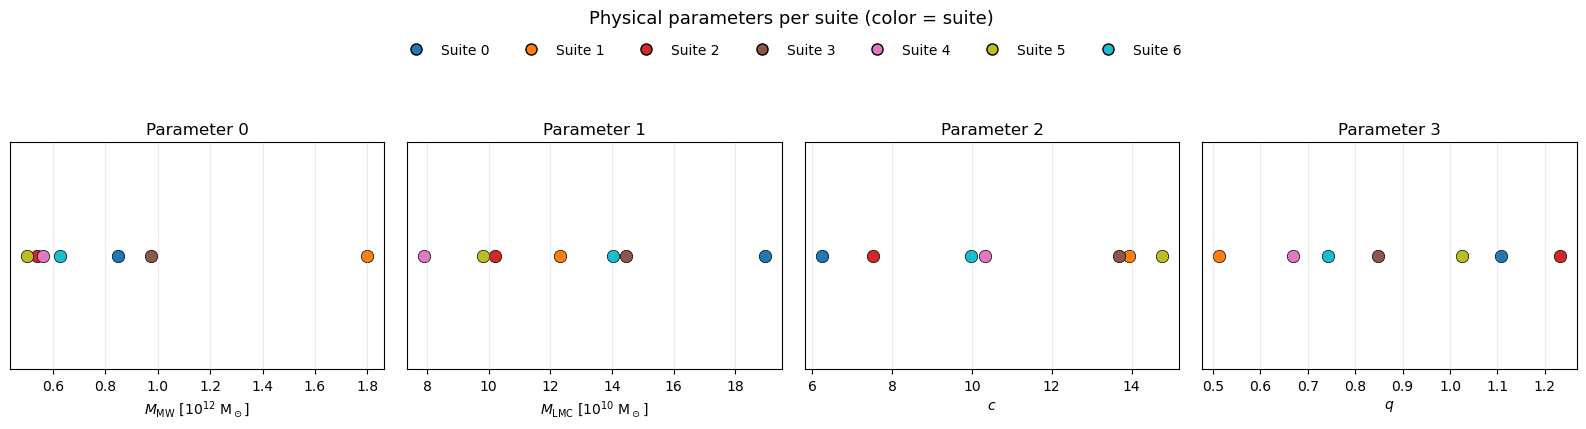

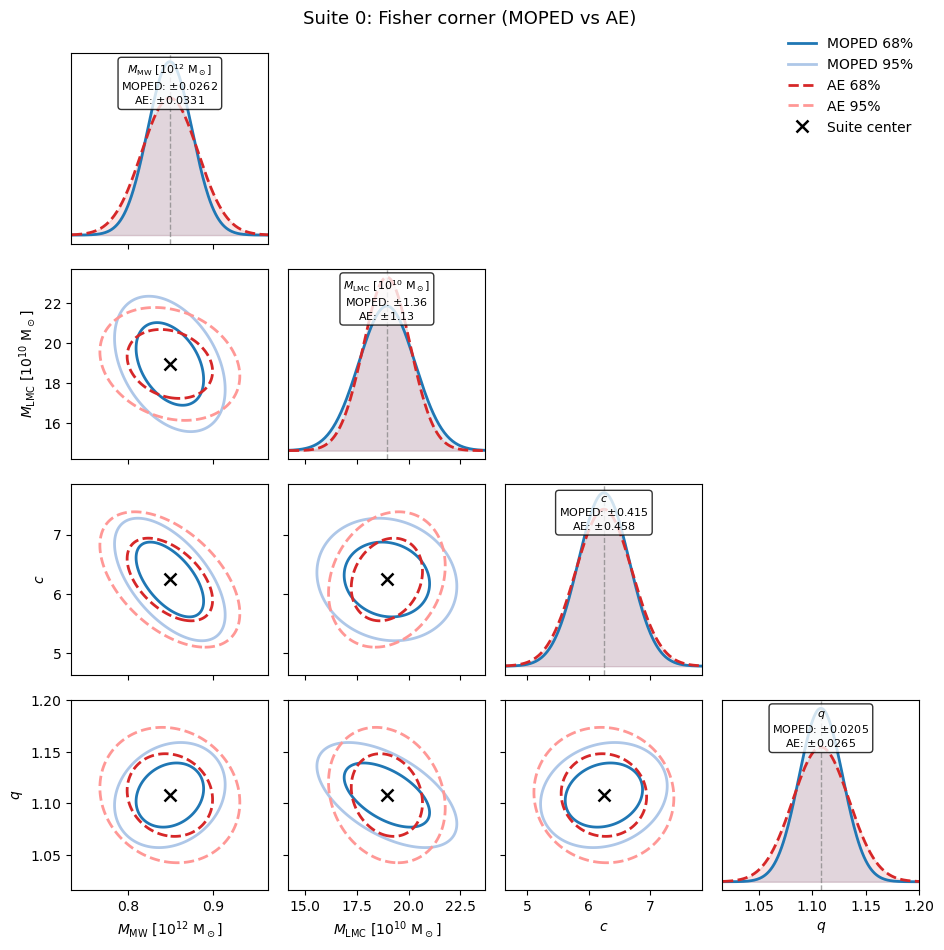

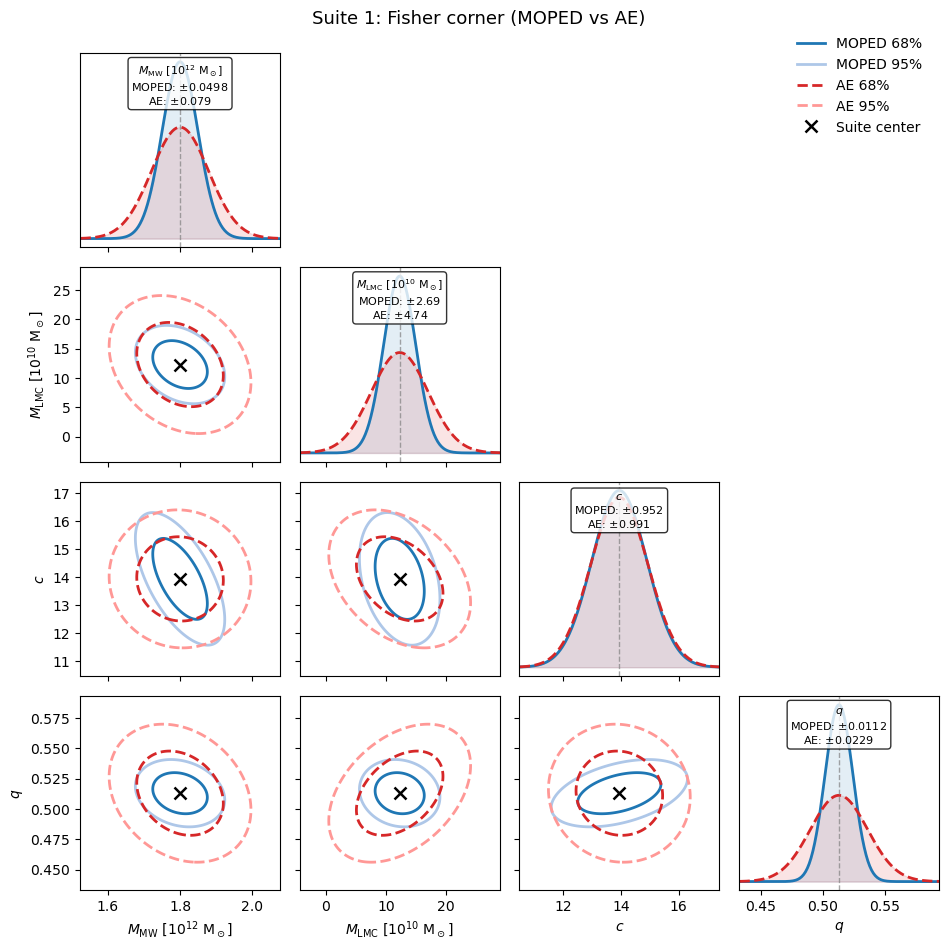

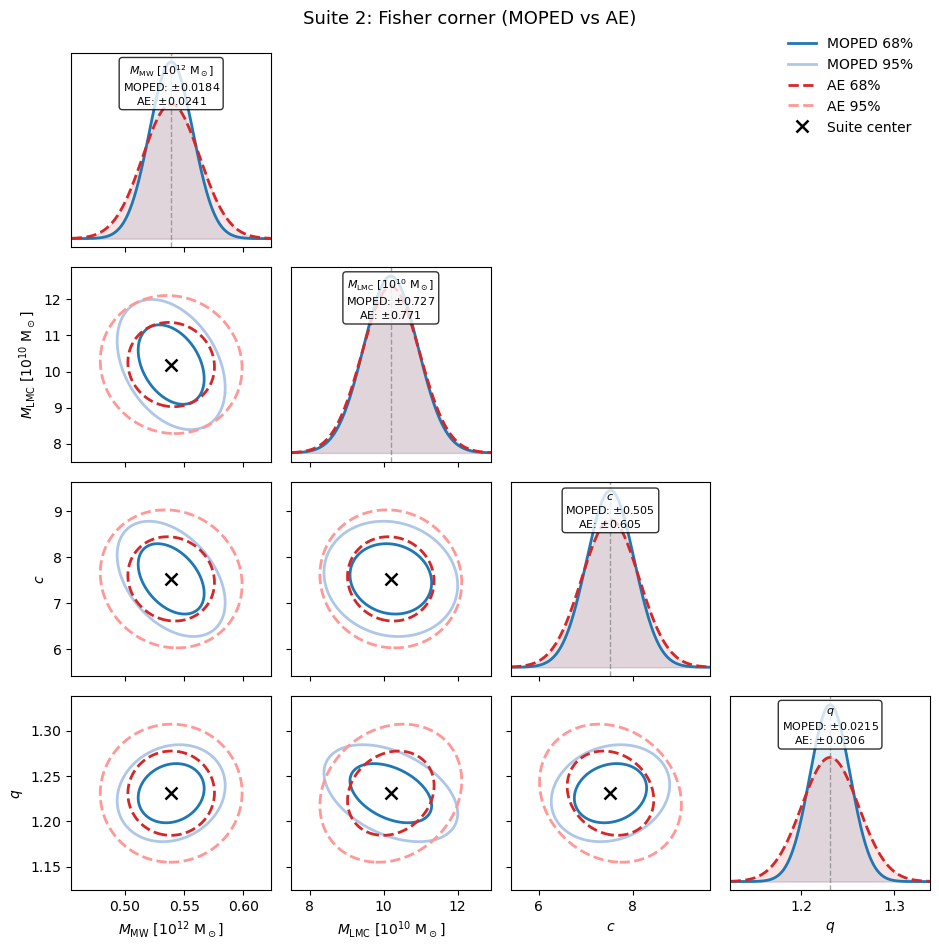

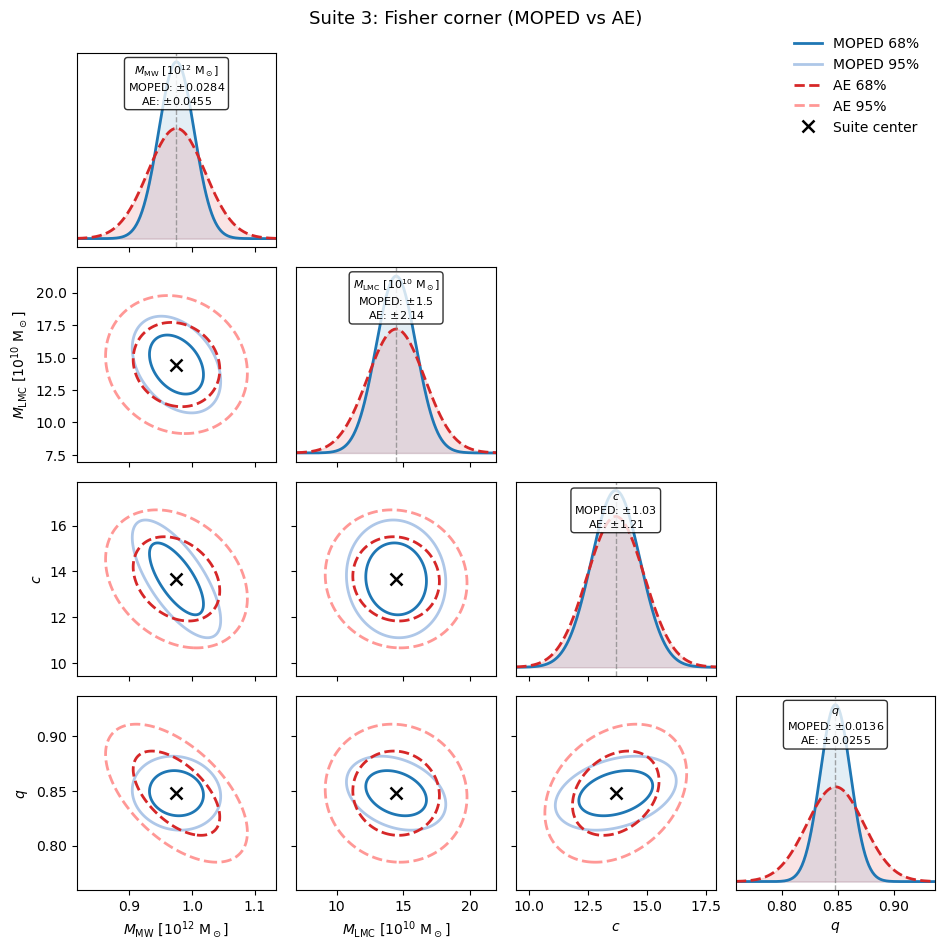

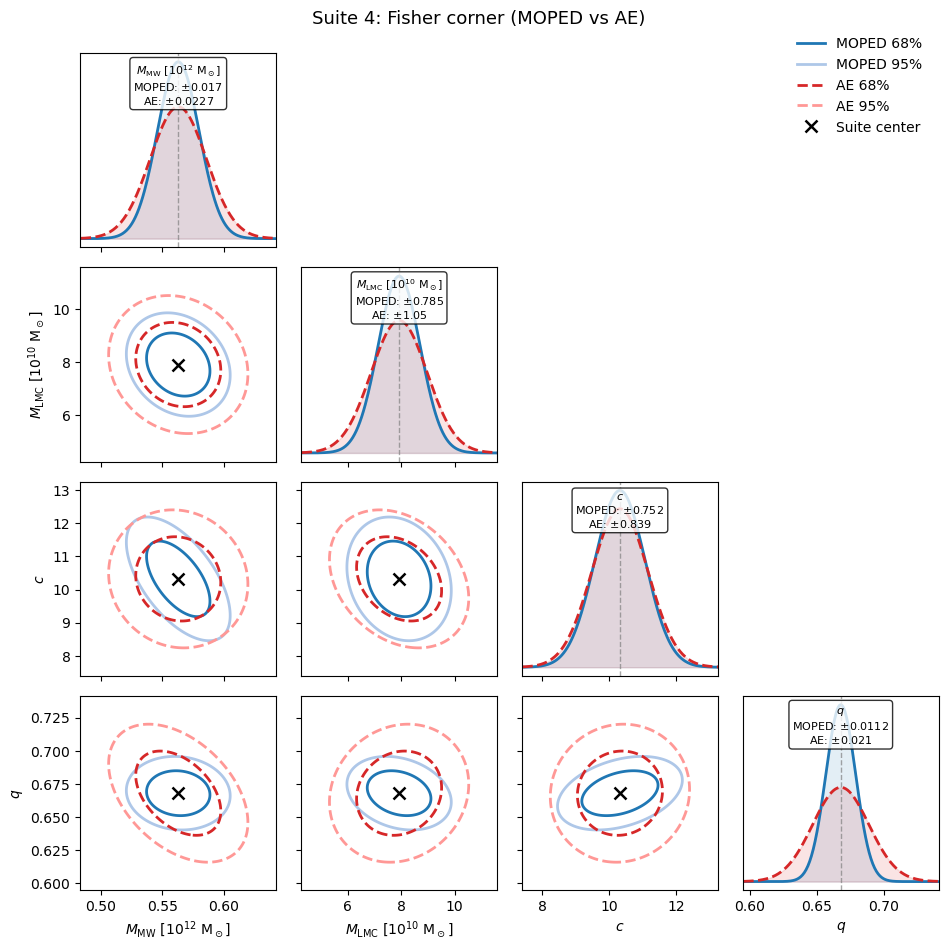

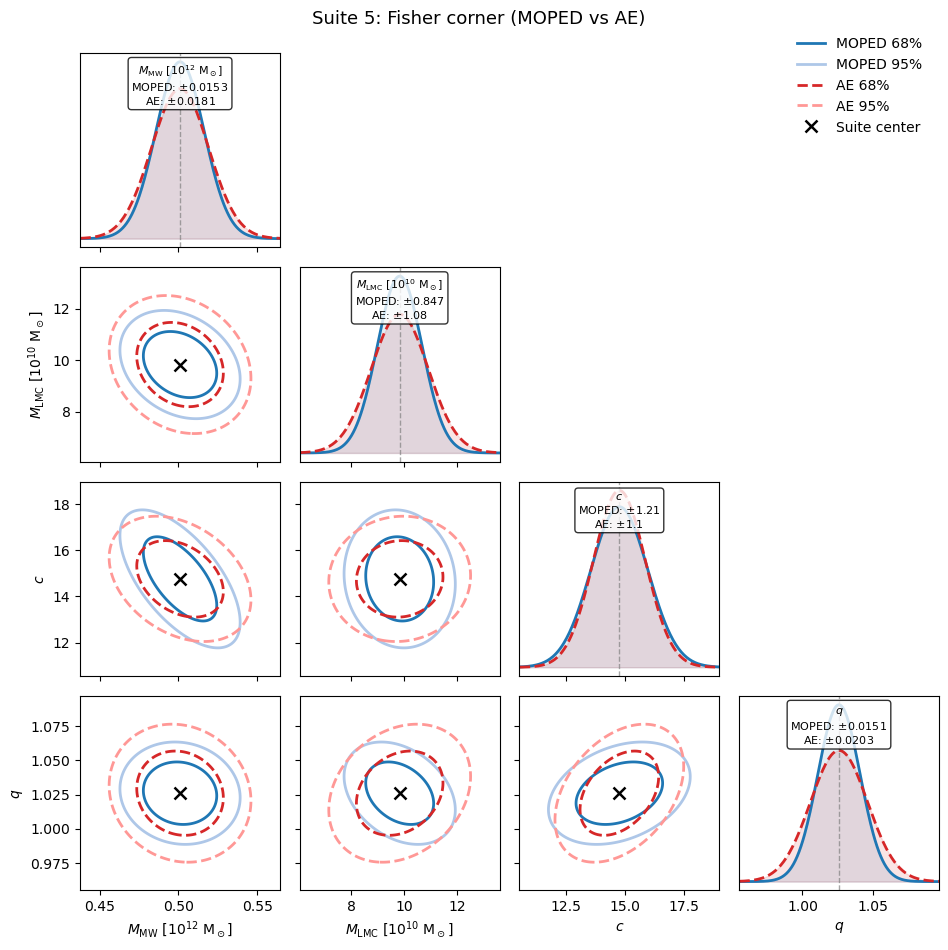

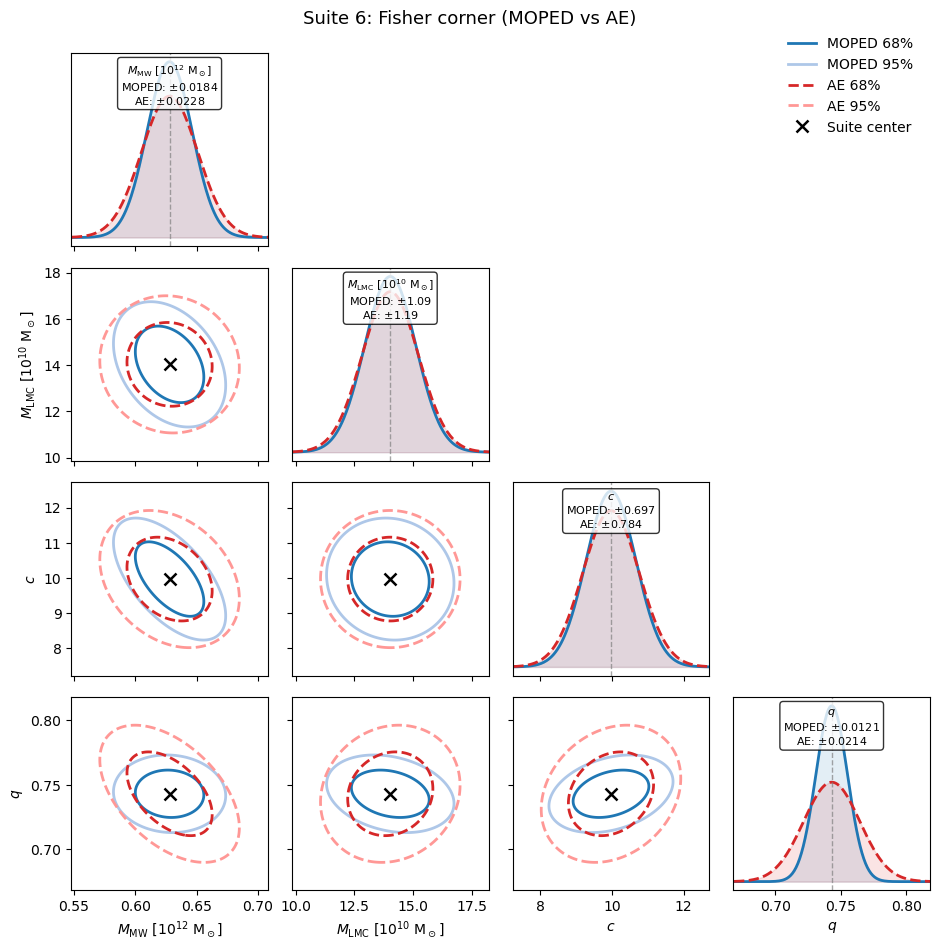

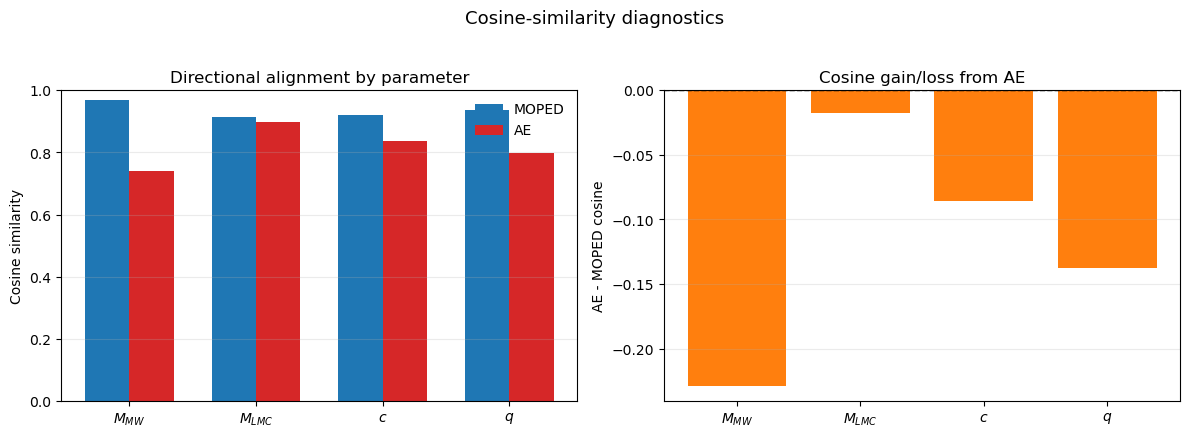

Cosine interpretation:
- Cosine ~ 1: derivative directions are well aligned with the parameter axis, so that parameter is cleanly identifiable.
- Lower cosine: stronger degeneracy/mixing with other parameters; constraints are less directionally pure.
- AE - MOPED > 0: AE improves directional alignment for that parameter; < 0 means MOPED aligns better.
- Mean cosine: MOPED=0.9350, AE=0.8175

Quick summary:
- Number of suites: 7
- Parameters: ['$M_{\\rm MW}$ [$10^{12}$ M$_\\odot$]', '$M_{\\rm LMC}$ [$10^{10}$ M$_\\odot$]', '$c$', '$q$']
- Corner labels: label1=MOPED, label2=AE


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

npz_path = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/BFE_samples_5k/test_theta_suites/test_suite_transfer_fisher_eval.npz"
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"File not found: {npz_path}")

D = np.load(npz_path, allow_pickle=True)
print(f"Loaded: {npz_path}")
print("Keys:", list(D.keys()))

def as_float(name):
    if name not in D:
        return None
    try:
        return np.asarray(D[name], dtype=float)
    except Exception:
        return None

suite_idx = as_float("suite_indices")
theta = as_float("suite_thetas")
sigma_lin = as_float("sigma_lin")
sigma_ae = as_float("sigma_ae")
J_lin = as_float("J_lin")
J_ae = as_float("J_ae")
cos_lin = as_float("cos_lin")
cos_ae = as_float("cos_ae")

if theta is None or sigma_lin is None or sigma_ae is None or J_lin is None or J_ae is None:
    raise ValueError("Missing required arrays: suite_thetas, sigma_lin, sigma_ae, J_lin, J_ae")

n_suite, n_param = theta.shape
if n_param != 4:
    raise ValueError(f"Expected 4 parameters, found {n_param}")

# Fisher covariance per suite: F = J^T J, Cov = F^{-1} (or pseudo-inverse)
cov_lin = np.zeros((n_suite, n_param, n_param), dtype=float)
cov_ae = np.zeros((n_suite, n_param, n_param), dtype=float)
for s in range(n_suite):
    Fl = J_lin[s].T @ J_lin[s]
    Fa = J_ae[s].T @ J_ae[s]
    try:
        cov_lin[s] = np.linalg.inv(Fl)
    except np.linalg.LinAlgError:
        cov_lin[s] = np.linalg.pinv(Fl)
    try:
        cov_ae[s] = np.linalg.inv(Fa)
    except np.linalg.LinAlgError:
        cov_ae[s] = np.linalg.pinv(Fa)

suite_labels = np.arange(n_suite) if suite_idx is None else suite_idx.astype(int)
param_labels = [
    r"$M_{\rm MW}$ [$10^{12}$ M$_\odot$]",
    r"$M_{\rm LMC}$ [$10^{10}$ M$_\odot$]",
    r"$c$",
    r"$q$",
]

label1 = "MOPED"
if "LATENT_DIM" in globals():
    label2 = f"AE (L={LATENT_DIM})"
else:
    label2 = "AE"

# ==================================================
# 1) Physical parameters of each suite (1x4 strip)
# ==================================================
cmap = plt.cm.get_cmap("tab10", n_suite)
colors = [cmap(i) for i in range(n_suite)]

fig_strip, axes_strip = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for p in range(4):
    ax = axes_strip[p]
    y = np.zeros(n_suite)
    for s in range(n_suite):
        ax.scatter(theta[s, p], y[s], s=80, color=colors[s], edgecolors='k', linewidths=0.5)
    ax.set_xlabel(param_labels[p])
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.25)
    ax.set_title(f"Parameter {p}")

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[s], markeredgecolor='k',
           markersize=8, label=f"Suite {suite_labels[s]}")
    for s in range(n_suite)
]
fig_strip.legend(handles=legend_handles, loc='upper center', ncol=min(n_suite, 7), frameon=False,
                 bbox_to_anchor=(0.5, 1.12))
fig_strip.suptitle("Physical parameters per suite (color = suite)", y=1.18, fontsize=13)
plt.tight_layout()
plt.show()

# ================================================================
# 2) Corner plots: Fisher contours (MOPED vs AE), one per suite
# ================================================================
def _corr_matrix(cov):
    """Compute correlation matrix from covariance, clamped to [-1, 1]."""
    d = np.sqrt(np.maximum(np.diag(cov), 0.0))
    d_safe = np.where(d > 0, d, 1.0)
    corr = cov / np.outer(d_safe, d_safe)
    return np.clip(corr, -1.0, 1.0)

def _rescaled_cov2d(corr_full, sig, idx_x, idx_y):
    """
    Build a 2x2 covariance using the true marginal sigmas (sig) and the
    correlation coefficient extracted from corr_full.
      C = [[sig_x^2,            rho * sig_x * sig_y],
           [rho * sig_x * sig_y, sig_y^2           ]]
    """
    rho = corr_full[idx_x, idx_y]
    sx, sy = sig[idx_x], sig[idx_y]
    return np.array([[sx*sx, rho*sx*sy],
                     [rho*sx*sy, sy*sy]])

def plot_suite_corner(theta0, cov1, cov2, sig1, sig2, suite_name, labels, label1="MOPED", label2="AE"):
    """
    Corner plot comparing two Fisher information matrices.

    sig1 / sig2  : correct 1D marginal sigmas (e.g. from the NPZ file).
    cov1 / cov2  : full covariance matrices used ONLY to extract correlations.

    The 2D panel for parameters (j, i) uses a covariance built from:
      - marginal sigmas sig1[j], sig1[i]  (same as the diagonal panel)
      - correlation rho = corr1[j, i]     (from inv(J^T J))
    This guarantees the 1D and 2D panels are always mutually consistent.

    2D chi2 confidence levels (2 dof):
      chi2 = 2.30  → 68% region   (projects to ±sqrt(2.30)*sigma on each axis ≈ ±1.52 sigma)
      chi2 = 6.17  → 95% region   (projects to ±sqrt(6.17)*sigma on each axis ≈ ±2.48 sigma)
    """
    n = len(labels)
    fig, axes = plt.subplots(n, n, figsize=(9.5, 9.5))

    colors_1 = ['#1f77b4', '#aec7e8']  # MOPED 68/95
    colors_2 = ['#d62728', '#ff9896']  # AE    68/95

    corr1 = _corr_matrix(cov1)
    corr2 = _corr_matrix(cov2)

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i < j:
                ax.axis('off')
                continue

            if i == j:
                mu = theta0[i]
                s1 = max(sig1[i], 1e-12)
                s2 = max(sig2[i], 1e-12)
                half = 4.0 * max(s1, s2)
                x = np.linspace(mu - half, mu + half, 250)
                y1 = np.exp(-0.5 * ((x - mu) / s1) ** 2) / (s1 * np.sqrt(2 * np.pi))
                y2 = np.exp(-0.5 * ((x - mu) / s2) ** 2) / (s2 * np.sqrt(2 * np.pi))
                ax.plot(x, y1, color=colors_1[0], lw=2)
                ax.plot(x, y2, color=colors_2[0], lw=2, ls='--')
                ax.fill_between(x, 0, y1, color=colors_1[0], alpha=0.12)
                ax.fill_between(x, 0, y2, color=colors_2[0], alpha=0.12)
                ax.axvline(mu, color='gray', ls='--', lw=1, alpha=0.7)
                txt = (
                    f"{labels[i]}\n"
                    f"{label1}: $\\pm {s1:.3g}$\n"
                    f"{label2}: $\\pm {s2:.3g}$"
                )
                ax.text(0.5, 0.95, txt, transform=ax.transAxes, ha='center', va='top', fontsize=8,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                ax.set_yticks([])
                ax.set_xlim(mu - 3.5 * max(s1, s2), mu + 3.5 * max(s1, s2))
                if i == n - 1:
                    ax.set_xlabel(labels[i])
                else:
                    ax.set_xticklabels([])
                continue

            # lower triangle: 2D chi2 ellipses
            # Rescale using true marginal sigmas + Fisher correlations
            mux, muy = theta0[j], theta0[i]
            C1 = _rescaled_cov2d(corr1, sig1, j, i)
            C2 = _rescaled_cov2d(corr2, sig2, j, i)

            sx = max(sig1[j], sig2[j], 1e-12)
            sy = max(sig1[i], sig2[i], 1e-12)

            xx = np.linspace(mux - 3.5 * sx, mux + 3.5 * sx, 200)
            yy = np.linspace(muy - 3.5 * sy, muy + 3.5 * sy, 200)
            X, Y = np.meshgrid(xx, yy)
            d = np.stack([X - mux, Y - muy], axis=-1)

            C1inv = np.linalg.pinv(C1)
            C2inv = np.linalg.pinv(C2)
            chi2_1 = np.einsum('...i,ij,...j->...', d, C1inv, d)
            chi2_2 = np.einsum('...i,ij,...j->...', d, C2inv, d)

            # Standard 2D confidence levels (chi2 with 2 dof)
            lev68, lev95 = 2.30, 6.17
            ax.contour(X, Y, chi2_1, levels=[lev68], colors=[colors_1[0]], linewidths=2)
            ax.contour(X, Y, chi2_1, levels=[lev95], colors=[colors_1[1]], linewidths=2)
            ax.contour(X, Y, chi2_2, levels=[lev68], colors=[colors_2[0]], linewidths=2, linestyles='--')
            ax.contour(X, Y, chi2_2, levels=[lev95], colors=[colors_2[1]], linewidths=2, linestyles='--')
            ax.plot(mux, muy, 'x', color='k', markersize=8, markeredgewidth=1.8)

            ax.set_xlim(mux - 3.5 * sx, mux + 3.5 * sx)
            ax.set_ylim(muy - 3.5 * sy, muy + 3.5 * sy)
            if i == n - 1:
                ax.set_xlabel(labels[j])
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i])
            else:
                ax.set_yticklabels([])

    handles = [
        Line2D([0], [0], color=colors_1[0], lw=2, label=f'{label1} 68%'),
        Line2D([0], [0], color=colors_1[1], lw=2, label=f'{label1} 95%'),
        Line2D([0], [0], color=colors_2[0], lw=2, ls='--', label=f'{label2} 68%'),
        Line2D([0], [0], color=colors_2[1], lw=2, ls='--', label=f'{label2} 95%'),
        Line2D([0], [0], marker='x', color='k', lw=0, markersize=8, markeredgewidth=1.8, label='Suite center')
    ]
    fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=False)
    fig.suptitle(f"Suite {suite_name}: Fisher corner ({label1} vs {label2})", y=0.995, fontsize=13)
    plt.tight_layout()
    plt.show()

for s in range(n_suite):
    plot_suite_corner(
        theta0=theta[s],
        cov1=cov_lin[s],
        cov2=cov_ae[s],
        sig1=sigma_lin[s],
        sig2=sigma_ae[s],
        suite_name=suite_labels[s],
        labels=param_labels,
        label1=label1,
        label2=label2,
    )

# ============================================
# 3) What cosine similarity tells us
# ============================================
if cos_lin is not None and cos_ae is not None:
    m = min(len(cos_lin), len(cos_ae), 4)
    p = np.arange(m)
    width = 0.35

    fig_cos, ax_cos = plt.subplots(1, 2, figsize=(12, 4.2))
    ax_cos[0].bar(p - width/2, cos_lin[:m], width=width, label=label1, color='#1f77b4')
    ax_cos[0].bar(p + width/2, cos_ae[:m], width=width, label=label2, color='#d62728')
    ax_cos[0].set_ylim(0, 1.0)
    ax_cos[0].set_xticks(p)
    ax_cos[0].set_xticklabels([r"$M_{MW}$", r"$M_{LMC}$", r"$c$", r"$q$"][:m])
    ax_cos[0].set_ylabel("Cosine similarity")
    ax_cos[0].set_title("Directional alignment by parameter")
    ax_cos[0].grid(axis='y', alpha=0.25)
    ax_cos[0].legend(frameon=False)

    delta = cos_ae[:m] - cos_lin[:m]
    ax_cos[1].axhline(0.0, color='k', ls='--', lw=1)
    ax_cos[1].bar(p, delta, color=np.where(delta >= 0, '#2ca02c', '#ff7f0e'))
    ax_cos[1].set_xticks(p)
    ax_cos[1].set_xticklabels([r"$M_{MW}$", r"$M_{LMC}$", r"$c$", r"$q$"][:m])
    ax_cos[1].set_ylabel(f"{label2} - {label1} cosine")
    ax_cos[1].set_title("Cosine gain/loss from AE")
    ax_cos[1].grid(axis='y', alpha=0.25)

    fig_cos.suptitle("Cosine-similarity diagnostics", y=1.03, fontsize=13)
    plt.tight_layout()
    plt.show()

    print("Cosine interpretation:")
    print("- Cosine ~ 1: derivative directions are well aligned with the parameter axis, so that parameter is cleanly identifiable.")
    print("- Lower cosine: stronger degeneracy/mixing with other parameters; constraints are less directionally pure.")
    print(f"- {label2} - {label1} > 0: AE improves directional alignment for that parameter; < 0 means MOPED aligns better.")
    print(f"- Mean cosine: {label1}={np.nanmean(cos_lin[:m]):.4f}, {label2}={np.nanmean(cos_ae[:m]):.4f}")
else:
    print("Cosine arrays not available in the NPZ file.")

print("\nQuick summary:")
print(f"- Number of suites: {n_suite}")
print(f"- Parameters: {param_labels}")
print(f"- Corner labels: label1={label1}, label2={label2}")


## Universal-SBI Summary Learning (Contrastive + Supervised Encoder)

This notebook now trains the neural compressor primarily for **universal SBI** across parameter space, rather than for pure local reconstruction around a single fiducial.

---

### Linear baseline: score-augmented MOPED compression

The raw BFE feature vector lives in $\mathbb{R}^D$ with $D\approx 16{,}800$ (density + velocity moments). We compress it to $K$ summaries ($K=200$ by default) using a **score + residual-PCA** basis built once at the fiducial $\theta_\star=[0.7,\;15,\;9.415,\;1.0]$.

**Step 1 — Score directions ($P=4$ vectors).**
For each parameter $p$, compute the derivative of the mean standardised feature:

$$
\mathbf{d}_p
= \frac{\langle \tilde{\mathbf{f}}(\theta_\star+\Delta\theta_p)\rangle
      - \langle \tilde{\mathbf{f}}(\theta_\star-\Delta\theta_p)\rangle}
       {2\,\Delta\theta_p}
\;\in\mathbb{R}^D,
$$

where $\tilde{\mathbf{f}}$ denotes the per-block standardised feature and the average $\langle\cdot\rangle$ is over 100 simulation seeds. Stack the four derivatives into $D_{\rm mat}=[\mathbf{d}_{M_{\rm MW}}\;\mathbf{d}_{M_{\rm LMC}}\;\mathbf{d}_c\;\mathbf{d}_q]\in\mathbb{R}^{D\times P}$ and QR-factorise:

$$
D_{\rm mat}=Q_{\rm score}\,R,\qquad Q_{\rm score}\in\mathbb{R}^{D\times P},\quad Q_{\rm score}^\top Q_{\rm score}=I_P.
$$

These $P$ columns span the locally Fisher-optimal subspace.

**Step 2 — Residuals in the score-orthogonal complement.**
Centre the $N_{\rm cov}=2000$ fiducial repeats:

$$
X_c = \tilde{F}_{\rm cov} - \mathbf{1}\,\boldsymbol{\mu}_{\rm std}^\top,
\qquad
X_{c,\perp} = X_c - X_c\,Q_{\rm score}\,Q_{\rm score}^\top.
$$

**Step 3 — Residual PCA.**
SVD of $X_{c,\perp}$ yields the top $(K-P)$ residual eigenvectors $Q_{\rm resid}\in\mathbb{R}^{D\times(K-P)}$. Concatenate:

$$
Q_{\rm ext}=[Q_{\rm score}\;|\;Q_{\rm resid}]\;\in\mathbb{R}^{D\times K}.
$$

**Compression map.** For any new raw feature $\mathbf{f}_{\rm raw}$:

$$
\mathbf{s}_{\rm lin}
= Q_{\rm ext}^\top\!\bigl(\tilde{\mathbf{f}}_{\rm raw}-\boldsymbol{\mu}_{\rm std}\bigr)
\;\in\mathbb{R}^K.
$$

The first $P$ entries are the classical MOPED scores; the remaining $K{-}P$ entries carry residual variance useful for SBI but not for the local Fisher matrix.

---

### Neural universal summary model (AE)

Learns latent summaries ($L=16$ dimensions) that are:
- informative about parameters (supervised regression),
- stable to simulation noise at fixed $\theta$ (group-based contrastive loss),
- well-conditioned for downstream inference (latent whitening penalty).

#### Training objective

$$
\mathcal{L} = \lambda_{\rm param}\,\mathcal{L}_{\rm param}
  + \lambda_{\rm contrast}\,\mathcal{L}_{\rm contrast}
  + \lambda_{\rm whiten}\,\mathcal{L}_{\rm whiten}
  + \mathbb{1}_{\rm recon}\,\lambda_{\rm recon}\,\mathcal{L}_{\rm recon}
$$

| Term | Description |
|------|-------------|
| $\mathcal{L}_{\rm param}$ | MSE between predicted and normalised parameters |
| $\mathcal{L}_{\rm contrast}$ | Supervised contrastive loss using group IDs |
| $\mathcal{L}_{\rm whiten}$ | Latent covariance regulariser toward $I$ |
| $\mathcal{L}_{\rm recon}$ | Optional reconstruction MSE (disabled by default) |

#### Why this is better for SBI

- Encourages summaries that generalise across the LHC parameter grid.
- Reduces seed/noise dependence for the same physical $\theta$.
- Produces better-behaved latent geometry for posterior estimators (NPE/NLE).

---

### Current key settings

| Setting | Description | Value |
|---------|-------------|-------|
| `N_SUMMARIES` | Linear summary dimension $K$ | 200 |
| `LATENT_DIM` | AE bottleneck dimension $L$ | 16 |
| `LAMBDA_PARAM` | Parameter supervision weight | 10.0 |
| `LAMBDA_CONTRAST` | Contrastive invariance weight | 1.0 |
| `LAMBDA_WHITEN` | Latent whitening weight | 0.05 |
| `USE_RECON_LOSS` | Include reconstruction term | False |
| `CONTRASTIVE_TEMP` | Contrastive temperature | 0.10 |
| `VAL_PARAM` | Held-out derivative groups | `"q"` |
| `VAL_LHC_FRAC` | Held-out LHC group fraction | 0.15 |

### Notes

- Both compressors (linear and AE) are built once at the fiducial $\theta_\star$ and then frozen. The universality test evaluates them at different $\theta$-suites without retraining.
- Group-split validation is retained to test generalisation to unseen $\theta$-groups.
- The downstream Fisher cell remains compatible because it still uses `model.encode(...)`.

## Cosine similarity: explicit definition

In this notebook, cosine similarity is computed from the **Jacobian columns** across suites.
For method $m\in\{\mathrm{MOPED},\mathrm{AE}\}$, suite $a$, and parameter $p$:

$$
J^{(m)}_a \in \mathbb{R}^{K_m\times P},\qquad
\mathbf{g}^{(m)}_{a,p}=J^{(m)}_a[:,p]=\frac{\partial \mathbf{s}^{(m)}}{\partial \theta_p}
$$

where $\mathbf{s}^{(m)}$ is the compressed summary vector and $P=4$ parameters here.

For two suites $a,b$, the pairwise cosine for parameter $p$ is

$$
c^{(m)}_{ab,p}
=\frac{\left(\mathbf{g}^{(m)}_{a,p}\right)^\top\mathbf{g}^{(m)}_{b,p}}
{\left\|\mathbf{g}^{(m)}_{a,p}\right\|_2\,\left\|\mathbf{g}^{(m)}_{b,p}\right\|_2}
\in[-1,1].
$$

The reported value in the notebook is the mean over all suite pairs:

$$
\bar c^{(m)}_p
=\frac{1}{N_{\rm pair}}\sum_{a<b} c^{(m)}_{ab,p},
\qquad N_{\rm pair}=\frac{N_{\rm suite}(N_{\rm suite}-1)}{2}.
$$

## Interpretation in this analysis

- $\bar c_p\approx 1$: derivative direction for parameter $p$ is stable across suites (good global consistency).
- $\bar c_p\approx 0$: derivative direction varies strongly with suite (poor global consistency).
- $\bar c_p<0$: frequent direction reversal/sign flip across suites (strong inconsistency).

This metric measures **directional consistency only**. It is insensitive to absolute derivative amplitude, so it should be interpreted together with Fisher uncertainties $\sigma_p$ (or $\sigma$ ratios) for tightness of constraints.